# 🎯 Logistic Regression — Probabilities, Odds Ratios & Decision Thresholds

> **What you'll learn:** how logistic regression turns a linear score into a probability, why its decision boundary is a straight line, why log loss *is* maximum likelihood, how `C`, L1/L2/elastic-net and the solvers work in scikit-learn 1.9, how to read coefficients as **odds ratios** with confidence intervals, what perfect separation does, and how to handle class imbalance, pick a **threshold for a stated cost**, and check **calibration**. You finish with a credit-risk model.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🟡 Intermediate → 🔴 Interview depth |
| **Time** | ~5 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [Linear Regression](03_Linear_Regression.ipynb) (least squares, regularization, statsmodels inference) · [ML Fundamentals From Scratch](01_ML_Fundamentals_From_Scratch.ipynb) (log loss, gradient descent, classification metrics, calibration basics) |
| **Tested with** | Python 3.12 · scikit-learn 1.9 · statsmodels 0.15 · numpy 2.5 · pandas 3.0 · scipy 1.18 · matplotlib 3.11 |
| **Interview relevance** | ⭐⭐⭐ Very high — "why is logistic regression a linear classifier?", "why log loss and not MSE?", "derive the gradient", "interpret this coefficient", "what happens with perfectly separable data?", "how do you choose the threshold?", class imbalance, OvR vs softmax, calibration |

## 🤔 What Is Logistic Regression?

Think of a **doctor's risk score**. Each finding adds or subtracts points:

```
score = −4.0 + 0.9 × (tumour radius) + 0.3 × (texture) + ...     ← a weighted sum, just like linear regression
probability of malignancy = 1 / (1 + e^(−score))                  ← squash the score into 0…1 with an S-curve
decision: order a biopsy if probability ≥ threshold               ← a separate, business/medical choice
```

That is logistic regression:
- The **score** $z = \beta_0 + \beta^\top x$ is linear, exactly as in linear regression. It is called the **log-odds** (or *logit*).
- The **sigmoid** $\sigma(z) = 1/(1+e^{-z})$ turns any score into a **probability** between 0 and 1.
- The model is trained with **log loss**, which heavily punishes confident wrong answers.
- A **threshold** turns probabilities into yes/no decisions. 0.5 is only the default, not a law.

Despite the name, logistic regression is a **classification** model ("regression" because it regresses the log-odds on the features).

## 🎯 Why It Matters

- **It is the default baseline for binary classification**: credit default, fraud, churn, click-through, disease risk, spam. Many production systems still run it because it is fast, stable and explainable.
- **Probabilities you can use.** Well-specified logistic models are usually well calibrated, so a "0.2" can drive pricing, triage or expected-cost decisions.
- **Explainability and regulation.** Coefficients become **odds ratios** with confidence intervals. Credit scorecards and medical risk scores are logistic regressions underneath.
- **It's inside deep learning.** The last layer of a neural-network classifier is logistic (sigmoid) or multinomial (softmax) regression on learned features.
- **In interviews** it is one of the most-asked models: *"why is it linear?"*, *"why not MSE?"*, *"derive the gradient"*, *"what does a coefficient of 0.7 mean?"*, *"what if the data is perfectly separable?"*, *"L1 vs L2 and what's C?"*, *"OvR vs softmax"*, *"how do you pick a threshold / handle imbalance?"*, *"is it calibrated?"*.

## 🃏 Algorithm Card

| | Logistic regression |
|---|---|
| **Learning type** | Supervised |
| **Tasks** | Binary classification; multiclass via multinomial (softmax) or one-vs-rest; probability estimation |
| **Model / objective** | $P(y=1\mid x) = \sigma(\beta_0 + \beta^\top x)$. Minimizes log loss (= negative Bernoulli log-likelihood). scikit-learn: $\min\; C\sum_i \ell_i + \tfrac{1-\rho}{2}\lVert w\rVert_2^2 + \rho\lVert w\rVert_1$ with $\rho$ = `l1_ratio` |
| **Key hyperparameters** | `C` (inverse regularization, 1e-3 – 1e3, log scale; default 1) · `l1_ratio` (0 = L2, 1 = L1, in between = elastic-net) · `solver` (`lbfgs` default, `liblinear`, `newton-cholesky`, `saga`, …) · `class_weight` · `max_iter`, `tol` · plus the **decision threshold** (tuned separately) |
| **Needs feature scaling?** | Yes for regularization to be fair and for fast solver convergence (predictions of an unpenalized model don't depend on it) |
| **Handles missing values / categoricals?** | No. Impute and one-hot encode first (drop a reference level for interpretable, unpenalized models) |
| **Training & prediction complexity** | lbfgs/newton-cg ≈ $O(np)$ per iteration; newton-cholesky $O(np^2 + p^3)$ per iteration; prediction $O(p)$ per row ($O(pK)$ for K classes) |
| **Interpretability** | Very high: odds ratios $e^{\beta_j}$ with CIs, additive log-odds contributions |
| **Strengths** | Fast, convex (one global optimum), probabilistic output, usually well calibrated, easy to regularize, explain and deploy, works well with many sparse features (text) |
| **Weaknesses** | Linear boundary unless you engineer features · affected by perfect separation · correlated features make coefficients unstable · weaker than boosting on complex tabular interactions |
| **Use it when** | You need a strong baseline, calibrated probabilities, explanations (odds ratios, reason codes), regulated models, or very high-dimensional sparse data |
| **Avoid it when** | The boundary is highly non-linear and you can't engineer features · you need the last bit of accuracy on large tabular data (try gradient boosting) |
| **Best libraries** | scikit-learn (`LogisticRegression`, `LogisticRegressionCV`, `TunedThresholdClassifierCV`, `CalibratedClassifierCV`) for prediction · `statsmodels` (`Logit`, `smf.logit`, marginal effects) for inference |

## ✅ By the End You Can

- [ ] Explain why linear regression fails for classification, and convert between probability, odds and log-odds
- [ ] Show that the decision boundary is a line (hyperplane) and that log loss is the negative log-likelihood, and derive its gradient
- [ ] Choose `C`, `l1_ratio` and a solver in scikit-learn 1.9, and explain why scaling speeds up convergence
- [ ] Fit multinomial and one-vs-rest models, and read coefficients as odds ratios with confidence intervals from `statsmodels`
- [ ] Diagnose perfect/quasi-separation and leakage, handle class imbalance, tune a threshold for a stated cost on validation data, and check calibration
- [ ] Build L2-regularized logistic regression from scratch (gradient descent and Newton) and match scikit-learn

## 📋 Table of Contents

1. [Why Linear Regression Fails for Classification](#1.-Why-Linear-Regression-Fails-for-Classification-🟢)
2. [The Sigmoid, Odds, and Log-Odds](#2.-The-Sigmoid,-Odds,-and-Log-Odds-🟢)
3. [The Decision Boundary Is a Straight Line](#3.-The-Decision-Boundary-Is-a-Straight-Line-🟢)
4. [Log Loss Is Maximum Likelihood](#4.-Log-Loss-Is-Maximum-Likelihood-🟡)
5. [Regularization: L2, L1, Elastic-Net, and C](#5.-Regularization:-L2,-L1,-Elastic-Net,-and-C-🟡)
6. [Solvers and Why Scaling Matters](#6.-Solvers-and-Why-Scaling-Matters-🟡)
7. [Multiclass: One-vs-Rest vs Multinomial (Softmax)](#7.-Multiclass:-One-vs-Rest-vs-Multinomial-(Softmax)-🟡)
8. [Coefficients as Odds Ratios With statsmodels](#8.-Coefficients-as-Odds-Ratios-With-statsmodels-🟡)
9. [Assumptions, Perfect Separation, and Quasi-Separation](#9.-Assumptions,-Perfect-Separation,-and-Quasi-Separation-🔴)
10. [Class Imbalance and class_weight](#10.-Class-Imbalance-and-class_weight-🟡)
11. [Tuning the Decision Threshold on Validation Data](#11.-Tuning-the-Decision-Threshold-on-Validation-Data-🟡)
12. [Calibration: Can You Trust the Probabilities?](#12.-Calibration:-Can-You-Trust-the-Probabilities?-🟡)
13. [Polynomial Features for Non-Linear Boundaries](#13.-Polynomial-Features-for-Non-Linear-Boundaries-🟡)
14. [Hyperparameters and a Fair Head-to-Head](#14.-Hyperparameters-and-a-Fair-Head-to-Head-🟡)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-Credit-Risk-Scoring-With-a-Cost-Based-Threshold) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a library is missing, uncomment the `%pip` line, run it once, then restart the kernel.

The `check()` helper gives you instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

Real datasets used (downloads are cached under `_outputs/datasets/`, about 4 MB in total):
- **Breast cancer Wisconsin** (scikit-learn): 569 tumours, 30 measurements. ⚠️ scikit-learn codes **0 = malignant, 1 = benign**; we explicitly make **malignant the positive class (1)**.
- **Wine** (scikit-learn): 178 wines from 3 cultivars, for multiclass.
- **Titanic** (OpenML 40945): 1,309 passengers, for odds ratios and separation.
- **Mammography** (OpenML): 11,183 regions of interest, 2.3% cancerous, for imbalance, thresholds and calibration.
- **Adult census income** (OpenML): age and weekly hours, for non-linear boundaries.
- **German credit** (OpenML 31 `credit-g`): 1,000 loan applicants, for the Mini Project.

⚠️ Never name a variable `C` in this notebook: `statsmodels` formulas use `C(...)` to mark categorical columns, and a global `C` would shadow it.

In [1]:
# %pip install -q "scikit-learn>=1.8" "statsmodels>=0.14" "numpy>=2.0" "pandas>=2.2" "scipy>=1.11" matplotlib

import sys
import time
import warnings
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
import statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.optimize import brentq
from scipy.special import expit, logit, softmax
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay, calibration_curve
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.datasets import fetch_openml, load_breast_cancer, load_wine
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.frozen import FrozenEstimator
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    RepeatedStratifiedKFold,
    StratifiedKFold,
    TunedThresholdClassifierCV,
    cross_val_predict,
    cross_validate,
    train_test_split,
    validation_curve,
)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, SplineTransformer, StandardScaler
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_class_weight

print(f"Python {sys.version.split()[0]} | scikit-learn {sklearn.__version__} | statsmodels {statsmodels.__version__} | "
      f"numpy {np.__version__} | pandas {pd.__version__} | scipy {scipy.__version__} | matplotlib {matplotlib.__version__}")

SEED = 42
rng = np.random.default_rng(SEED)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 130)
OUTPUT_DIR = Path("_outputs")                 # files we write go here (ignored by git)
DATA_DIR = OUTPUT_DIR / "datasets"            # dataset cache
DATA_DIR.mkdir(parents=True, exist_ok=True)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


def check(name, got, expected, hint="", rtol=1e-4, atol=1e-6):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    if isinstance(expected, (bool, np.bool_, str)):
        ok = got == expected
    elif isinstance(expected, (list, tuple)) and expected and isinstance(expected[0], str):
        ok = list(got) == list(expected)
    else:
        try:
            g, e = np.asarray(got, dtype=float), np.asarray(expected, dtype=float)
        except (TypeError, ValueError):
            raise AssertionError(f"❌ {name}: expected a number/array, got {type(got).__name__}. {hint}")
        if g.shape != e.shape:
            raise AssertionError(f"❌ {name}: shape {g.shape}, expected {e.shape}. {hint}")
        ok = np.allclose(g, e, rtol=rtol, atol=atol)
    assert ok, f"❌ {name}: not quite. {hint}"
    print(f"✅ {name}: correct!")


cancer = load_breast_cancer(as_frame=True)
print("scikit-learn's coding:", dict(enumerate(cancer.target_names)))
X_bc = cancer.data
y_bc = (cancer.target == 0).astype(int).rename("malignant")      # 1 = malignant (the class we want to catch)
X_train, X_val, y_train, y_val = train_test_split(X_bc, y_bc, test_size=0.25, stratify=y_bc, random_state=SEED)
print(f"breast cancer: train {X_train.shape} · validation {X_val.shape} · malignant share {y_bc.mean():.1%}")

Python 3.12.11 | scikit-learn 1.9.1 | statsmodels 0.15.0 | numpy 2.5.3 | pandas 3.0.5 | scipy 1.18.1 | matplotlib 3.11.2
scikit-learn's coding: {0: np.str_('malignant'), 1: np.str_('benign')}
breast cancer: train (426, 30) · validation (143, 30) · malignant share 37.3%


## 1. Why Linear Regression Fails for Classification 🟢

Why not just fit a straight line to the 0/1 labels and predict "malignant" when the line is above 0.5? This is called the **linear probability model**. Three problems:
1. **Predictions escape [0, 1].** A "probability" of 1.3 or −0.2 is meaningless.
2. **Easy, correct points move the boundary.** Very large tumours are all malignant and already classified correctly, but squared error still punishes the line for not reaching exactly 1 there. So the line tilts and the 0.5 cut-off moves.
3. **The errors can't be normal or constant-variance**: a 0/1 outcome has variance $p(1-p)$, which changes with $p$.

Let's test problem 2 with one feature, `mean area`. We fit both models twice, **with and without the 10% largest tumours**, and see how far each model's 0.5 cut-off moves. (Here logistic regression uses a huge `C`, i.e. almost no regularization, to compare like with like.)

In [2]:
feature = "mean area"
x_area = X_train[[feature]]
largest = X_train[feature] > X_train[feature].quantile(0.90)
print(f"the {int(largest.sum())} largest tumours in training are {y_train[largest].mean():.0%} malignant — easy, correct cases")

linear_all = LinearRegression().fit(x_area, y_train)
linear_trim = LinearRegression().fit(x_area[~largest], y_train[~largest])
logistic_all = LogisticRegression(C=1e6, max_iter=5000).fit(x_area, y_train)
logistic_trim = LogisticRegression(C=1e6, max_iter=5000).fit(x_area[~largest], y_train[~largest])


def linear_cutoff(model):
    return (0.5 - model.intercept_) / model.coef_[0]          # where the line crosses 0.5


def logistic_cutoff(model):
    return -model.intercept_[0] / model.coef_[0, 0]           # where the log-odds cross 0 (p = 0.5)


cutoffs = {"linear, all rows": linear_cutoff(linear_all), "linear, without largest 10%": linear_cutoff(linear_trim),
           "logistic, all rows": logistic_cutoff(logistic_all), "logistic, without largest 10%": logistic_cutoff(logistic_trim)}
cutoff_table = pd.DataFrame({"cut-off (mean area)": cutoffs,
                             "validation accuracy": {k: ((X_val[feature] >= v).astype(int) == y_val).mean() for k, v in cutoffs.items()}})
print(cutoff_table.round(3).to_string())

linear_pred = linear_all.predict(x_area)
shift_linear = cutoffs["linear, all rows"] - cutoffs["linear, without largest 10%"]
shift_logistic = cutoffs["logistic, all rows"] - cutoffs["logistic, without largest 10%"]
print(f"\n→ {np.mean((linear_pred < 0) | (linear_pred > 1)):.1%} of the linear model's training 'probabilities' fall outside [0, 1].")
print(f"→ Removing correct, easy cases moved the linear cut-off by {shift_linear:.0f} units of area; the logistic cut-off moved by {shift_logistic:.1f}.")

the 43 largest tumours in training are 100% malignant — easy, correct cases
                               cut-off (mean area)  validation accuracy
linear, all rows                           795.093                0.860
linear, without largest 10%                706.428                0.867
logistic, all rows                         684.044                0.867
logistic, without largest 10%              684.325                0.867

→ 8.5% of the linear model's training 'probabilities' fall outside [0, 1].
→ Removing correct, easy cases moved the linear cut-off by 89 units of area; the logistic cut-off moved by -0.3.


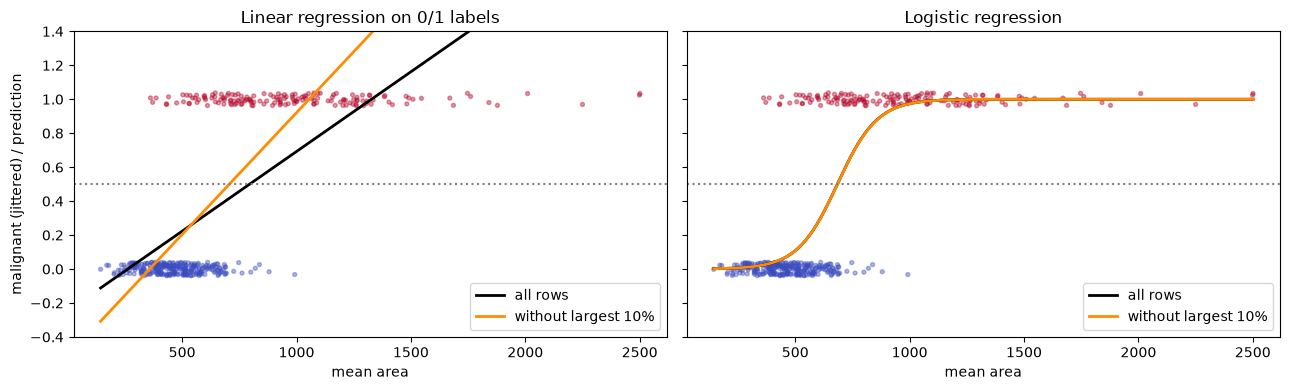

In [3]:
area_grid = pd.DataFrame({feature: np.linspace(X_bc[feature].min(), X_bc[feature].max(), 300)})
jitter = rng.uniform(-0.04, 0.04, len(y_train))
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, (label_all, model_all), (label_trim, model_trim), title in [
        (axes[0], ("all rows", linear_all), ("without largest 10%", linear_trim), "Linear regression on 0/1 labels"),
        (axes[1], ("all rows", logistic_all), ("without largest 10%", logistic_trim), "Logistic regression")]:
    ax.scatter(x_area[feature], y_train + jitter, s=8, alpha=0.4, c=y_train, cmap="coolwarm")
    for (label, model), color in [((label_all, model_all), "black"), ((label_trim, model_trim), "darkorange")]:
        curve = model.predict(area_grid) if isinstance(model, LinearRegression) else model.predict_proba(area_grid)[:, 1]
        ax.plot(area_grid[feature], curve, color=color, lw=2, label=label)
    ax.axhline(0.5, ls=":", color="gray")
    ax.set(xlabel="mean area", title=title, ylim=(-0.4, 1.4))
    ax.legend(loc="lower right")
axes[0].set_ylabel("malignant (jittered) / prediction")
plt.tight_layout()
plt.show()

The linear model's line tilts to accommodate the huge, obviously malignant tumours, and its cut-off shifts. The logistic curve simply flattens near 1 for those points (they are already "explained"), so its cut-off barely moves.

### ✍️ Your Turn

Using `linear_trim` (the line fitted without the largest tumours), compute the fraction of **validation** predictions that fall **above 1 or below 0**. Store it in `share_outside`.

In [4]:
share_outside = None  # TODO: your code here
check("share_outside", share_outside,
      np.mean((linear_trim.predict(X_val[[feature]]) > 1) | (linear_trim.predict(X_val[[feature]]) < 0)),
      hint="pred = linear_trim.predict(X_val[[feature]]); np.mean((pred > 1) | (pred < 0))")

⏳ share_outside: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
pred_trim = linear_trim.predict(X_val[[feature]])
share_outside = np.mean((pred_trim > 1) | (pred_trim < 0))
check("share_outside", share_outside,
      np.mean((linear_trim.predict(X_val[[feature]]) > 1) | (linear_trim.predict(X_val[[feature]]) < 0)))
print(f"{share_outside:.1%} of validation 'probabilities' are impossible")
```

Without the big tumours the line is steeper, so even more validation predictions shoot past 1: the linear probability model is fragile exactly where you'd want it to be confident.
</details>

> 💡 **Interview angle:** "Why not use linear regression for classification?" — unbounded outputs, a boundary that moves because of easy correct points far from it (squared error punishes them), and error assumptions that can't hold for 0/1 targets. Logistic regression models the log-odds linearly and uses log loss, so outputs are probabilities and confident correct points barely matter.

## 2. The Sigmoid, Odds, and Log-Odds 🟢

Three ways to say the same thing:

| Scale | Formula | Range | Example |
|---|---|---|---|
| **Probability** | $p$ | 0 … 1 | 0.8 |
| **Odds** | $\dfrac{p}{1-p}$ | 0 … ∞ | 4 ("4 to 1") |
| **Log-odds (logit)** | $\log\dfrac{p}{1-p}$ | −∞ … ∞ | 1.386 |

Logistic regression says the **log-odds are linear**: $\log\frac{p}{1-p} = \beta_0 + \beta^\top x$. Inverting gives the **sigmoid**, $p = \sigma(z) = \frac{1}{1+e^{-z}}$.

**Reading a coefficient.** A +1 change in $x_j$ adds $\beta_j$ to the log-odds, which **multiplies the odds by $e^{\beta_j}$** (the **odds ratio**). The change in *probability* depends on where you start: the curve is steepest at $p = 0.5$, where the slope is $\beta_j/4$ (the "divide by 4" rule of thumb).

In [5]:
probs = np.array([0.01, 0.2, 0.5, 0.8, 0.99])
print(pd.DataFrame({"probability p": probs, "odds p/(1−p)": probs / (1 - probs), "log-odds logit(p)": logit(probs)}).round(4).to_string(index=False))

radius_model = LogisticRegression(C=1e6, max_iter=5000).fit(X_train[["mean radius"]], y_train)
b0, b1 = radius_model.intercept_[0], radius_model.coef_[0, 0]
print(f"\nfitted: log-odds(malignant) = {b0:.3f} + {b1:.3f} × mean radius")
print(f"+1 unit of mean radius multiplies the odds of malignancy by e^{b1:.3f} = {np.exp(b1):.2f}")
radius_50 = -b0 / b1
for r in [10.0, radius_50, 16.0, 20.0]:
    p_r = radius_model.predict_proba(pd.DataFrame({"mean radius": [r]}))[0, 1]
    print(f"  mean radius {r:5.2f}: log-odds {b0 + b1 * r:+.2f} → odds {np.exp(b0 + b1 * r):8.3f} → probability {p_r:.3f}")
eps = 1e-4
numeric_slope = (radius_model.predict_proba(pd.DataFrame({"mean radius": [radius_50 + eps]}))[0, 1]
                 - radius_model.predict_proba(pd.DataFrame({"mean radius": [radius_50 - eps]}))[0, 1]) / (2 * eps)
print(f"slope of p at the 50% point: numeric {numeric_slope:.4f} vs β/4 = {b1 / 4:.4f}")

 probability p  odds p/(1−p)  log-odds logit(p)
          0.01        0.0101            -4.5951
          0.20        0.2500            -1.3863
          0.50        1.0000             0.0000
          0.80        4.0000             1.3863
          0.99       99.0000             4.5951

fitted: log-odds(malignant) = -14.992 + 1.012 × mean radius
+1 unit of mean radius multiplies the odds of malignancy by e^1.012 = 2.75
  mean radius 10.00: log-odds -4.87 → odds    0.008 → probability 0.008
  mean radius 14.81: log-odds +0.00 → odds    1.000 → probability 0.500
  mean radius 16.00: log-odds +1.21 → odds    3.344 → probability 0.770
  mean radius 20.00: log-odds +5.26 → odds  191.951 → probability 0.995
slope of p at the 50% point: numeric 0.2531 vs β/4 = 0.2531


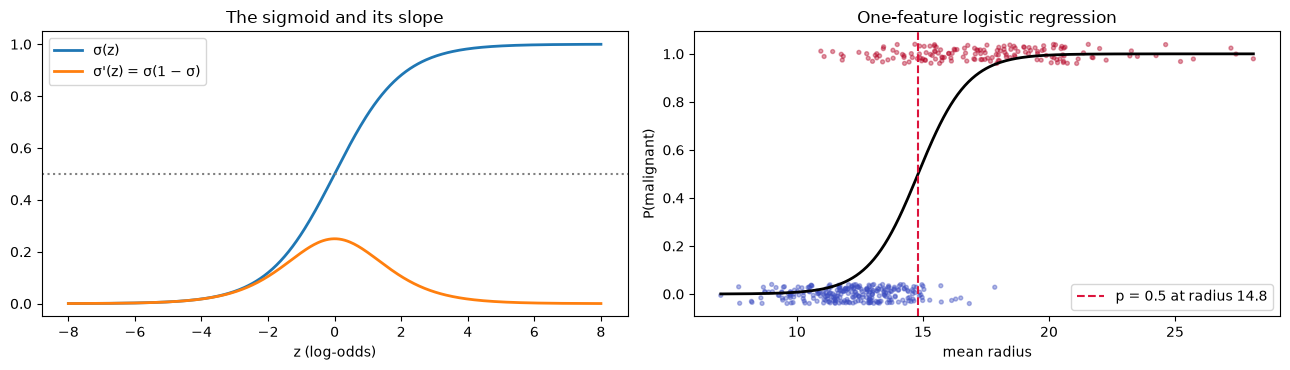

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
z = np.linspace(-8, 8, 400)
axes[0].plot(z, expit(z), lw=2, label="σ(z)")
axes[0].plot(z, expit(z) * (1 - expit(z)), lw=2, label="σ'(z) = σ(1 − σ)")
axes[0].axhline(0.5, ls=":", color="gray")
axes[0].set(xlabel="z (log-odds)", title="The sigmoid and its slope")
axes[0].legend()
radius_grid = pd.DataFrame({"mean radius": np.linspace(X_bc["mean radius"].min(), X_bc["mean radius"].max(), 300)})
axes[1].scatter(X_train["mean radius"], y_train + rng.uniform(-0.04, 0.04, len(y_train)), s=8, alpha=0.4, c=y_train, cmap="coolwarm")
axes[1].plot(radius_grid["mean radius"], radius_model.predict_proba(radius_grid)[:, 1], color="black", lw=2)
axes[1].axvline(radius_50, ls="--", color="crimson", label=f"p = 0.5 at radius {radius_50:.1f}")
axes[1].set(xlabel="mean radius", ylabel="P(malignant)", title="One-feature logistic regression")
axes[1].legend()
plt.tight_layout()
plt.show()

**Numerical stability.** For a very negative $z$, `np.exp(-z)` overflows. Use `scipy.special.expit` for the sigmoid, and compute log loss from $z$ with `np.logaddexp(0, z) - y*z` rather than `log(sigmoid(z))`.

In [7]:
z_extreme = np.array([-1000.0, 0.0, 1000.0])
try:
    with np.errstate(over="raise"):
        naive_sigmoid = 1 / (1 + np.exp(-z_extreme))
except FloatingPointError as err:
    print(f"❌ naive 1/(1+exp(-z)) for z = -1000: FloatingPointError: {err}")
print("✅ scipy.special.expit:", expit(z_extreme))
with np.errstate(divide="ignore"):
    print("❌ log(expit(z)) for z = -1000 (log-likelihood of y=1):", np.log(expit(-1000.0)))
print("✅ -np.logaddexp(0, -z) for z = -1000:", -np.logaddexp(0, 1000.0))

❌ naive 1/(1+exp(-z)) for z = -1000: FloatingPointError: overflow encountered in exp
✅ scipy.special.expit: [0.  0.5 1. ]
❌ log(expit(z)) for z = -1000 (log-likelihood of y=1): -inf
✅ -np.logaddexp(0, -z) for z = -1000: -1000.0


### ✍️ Your Turn

Compute the log-odds of $p = 0.9$ and the probability for a log-odds of $z = 2$, **with the formulas** (not `logit`/`expit`). Store them in `log_odds_09` and `prob_z2`.

In [8]:
log_odds_09 = None  # TODO
prob_z2 = None  # TODO
check("log_odds_09", log_odds_09, logit(0.9), hint="np.log(p / (1 - p))")
check("prob_z2", prob_z2, expit(2.0), hint="1 / (1 + np.exp(-z))")

⏳ log_odds_09: not attempted yet — replace None with your answer.
⏳ prob_z2: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
log_odds_09 = np.log(0.9 / (1 - 0.9))
prob_z2 = 1 / (1 + np.exp(-2.0))
check("log_odds_09", log_odds_09, logit(0.9))
check("prob_z2", prob_z2, expit(2.0))
```

$p = 0.9$ means odds of 9 to 1 and log-odds $\ln 9 \approx 2.197$. A log-odds of 2 gives $p \approx 0.881$.
</details>

> 💡 **Interview angle:** "What does a coefficient of 0.7 mean in logistic regression?" — a one-unit increase adds 0.7 to the log-odds, i.e. multiplies the **odds** by $e^{0.7} \approx 2.01$, holding other features fixed. It does **not** add a fixed amount to the probability: that depends on the starting point (at most $0.7/4 = 0.175$ near $p=0.5$).

## 3. The Decision Boundary Is a Straight Line 🟢

We predict class 1 when $p \ge 0.5$, i.e. when $\sigma(z) \ge 0.5$, i.e. when $z = \beta_0 + \beta^\top x \ge 0$. The set $\{x : \beta_0 + \beta^\top x = 0\}$ is a **straight line** in 2-D, a plane in 3-D, a **hyperplane** in general. That is why logistic regression is a **linear classifier**, even though the probability curve is an S-shape.

Any other threshold $t$ gives $z = \text{logit}(t)$: a **parallel** line shifted towards one class. Let's draw it with two real features.

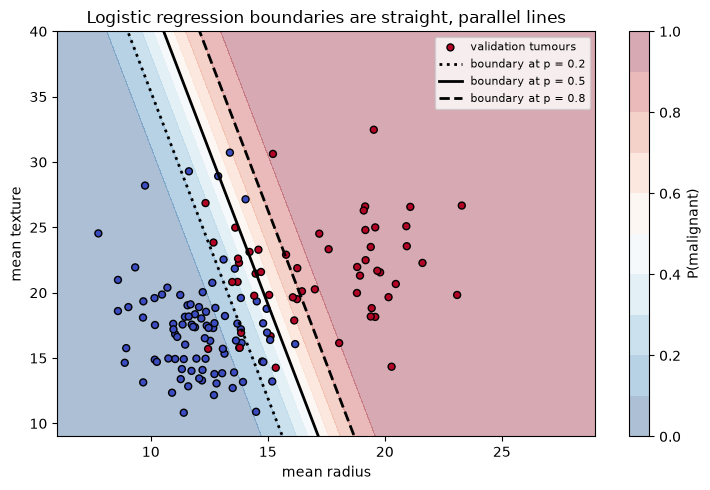

validation accuracy with 2 features: 0.881 | malignant recall 0.736
boundary (standardized units): -0.703 +3.232·radius_z +0.825·texture_z = 0


In [9]:
two = ["mean radius", "mean texture"]
boundary_pipe = make_pipeline(StandardScaler(), LogisticRegression()).fit(X_train[two], y_train)
scaler_2d, w_2d, b_2d = boundary_pipe[0], boundary_pipe[-1].coef_[0], boundary_pipe[-1].intercept_[0]


def boundary_texture(radius, threshold=0.5):
    """Mean texture on the line where P(malignant) = threshold, for a given mean radius."""
    z_target = logit(threshold)
    z_radius = w_2d[0] * (radius - scaler_2d.mean_[0]) / scaler_2d.scale_[0]
    return scaler_2d.mean_[1] + scaler_2d.scale_[1] * (z_target - b_2d - z_radius) / w_2d[1]


r_grid, t_grid = np.meshgrid(np.linspace(6, 29, 250), np.linspace(9, 40, 250))
proba_grid = boundary_pipe.predict_proba(pd.DataFrame({"mean radius": r_grid.ravel(), "mean texture": t_grid.ravel()}))[:, 1].reshape(r_grid.shape)

fig, ax = plt.subplots(figsize=(7.5, 5))
filled = ax.contourf(r_grid, t_grid, proba_grid, levels=np.linspace(0, 1, 11), cmap="RdBu_r", alpha=0.35)
fig.colorbar(filled, ax=ax, label="P(malignant)")
ax.scatter(X_val["mean radius"], X_val["mean texture"], c=y_val, cmap="coolwarm", edgecolor="k", s=25, label="validation tumours")
radius_line = np.linspace(6, 29, 50)
for threshold, style in [(0.2, ":"), (0.5, "-"), (0.8, "--")]:
    ax.plot(radius_line, boundary_texture(radius_line, threshold), "k", ls=style, lw=2, label=f"boundary at p = {threshold}")
ax.set(xlim=(6, 29), ylim=(9, 40), xlabel="mean radius", ylabel="mean texture", title="Logistic regression boundaries are straight, parallel lines")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

val_pred_2d = boundary_pipe.predict(X_val[two])
print(f"validation accuracy with 2 features: {accuracy_score(y_val, val_pred_2d):.3f} | "
      f"malignant recall {recall_score(y_val, val_pred_2d):.3f}")
print(f"boundary (standardized units): {b_2d:+.3f} {w_2d[0]:+.3f}·radius_z {w_2d[1]:+.3f}·texture_z = 0")

### ✍️ Your Turn

Find the **mean texture** at which a tumour with **mean radius 15** sits exactly on the p = 0.5 boundary. Use `scaler_2d`, `w_2d` and `b_2d` (you may call `boundary_texture`, but try the algebra first). Store it in `texture_at_15`. The checker finds the answer independently by root-finding on `predict_proba`.

In [10]:
texture_at_15 = None  # TODO: your code here
texture_reference = brentq(lambda tex: boundary_pipe.predict_proba(pd.DataFrame({"mean radius": [15.0], "mean texture": [tex]}))[0, 1] - 0.5, -50, 150)
check("texture_at_15", texture_at_15, texture_reference, rtol=1e-6,
      hint="Solve b + w0·(15 − m0)/s0 + w1·(t − m1)/s1 = 0 for t.")

⏳ texture_at_15: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
z_radius = w_2d[0] * (15.0 - scaler_2d.mean_[0]) / scaler_2d.scale_[0]
texture_at_15 = scaler_2d.mean_[1] + scaler_2d.scale_[1] * (-b_2d - z_radius) / w_2d[1]
texture_reference = brentq(lambda tex: boundary_pipe.predict_proba(pd.DataFrame({"mean radius": [15.0], "mean texture": [tex]}))[0, 1] - 0.5, -50, 150)
check("texture_at_15", texture_at_15, texture_reference, rtol=1e-6)
```

Setting the log-odds to zero is a linear equation, so the boundary texture is a linear function of radius: a straight line.
</details>

> 💡 **Interview angle:** "Why is logistic regression a linear classifier if the sigmoid is non-linear?" — the decision $p \ge t$ is equivalent to $\beta_0 + \beta^\top x \ge \text{logit}(t)$ because the sigmoid is monotonic, so the boundary is a hyperplane in feature space. Non-linear boundaries require non-linear features (polynomials, splines, interactions), which is Section 13.

## 4. Log Loss Is Maximum Likelihood 🟡

Treat each label as a coin flip with its own probability $p_i = \sigma(\beta^\top x_i)$ (a **Bernoulli** outcome). The likelihood of all labels is

$$L(\beta) = \prod_i p_i^{\,y_i}(1-p_i)^{1-y_i} \quad\Longrightarrow\quad -\log L(\beta) = \sum_i -\big[y_i\log p_i + (1-y_i)\log(1-p_i)\big] = n \cdot \text{log loss}$$

So **minimizing log loss = maximizing the likelihood**. Its derivatives are beautifully simple (derived step by step in [ML Fundamentals, Section 5](01_ML_Fundamentals_From_Scratch.ipynb)):

$$\nabla_\beta(-\log L) = X^\top(p - y), \qquad \nabla^2_\beta(-\log L) = X^\top S X,\; S = \text{diag}\big(p_i(1-p_i)\big)$$

The Hessian $X^\top S X$ is positive semi-definite, so the loss is **convex**: gradient descent or Newton's method finds the global minimum (if it exists; see Section 9).

**Why not MSE?** With $\text{MSE} = (\sigma(z) - y)^2$ the gradient picks up an extra factor $\sigma'(z) = p(1-p)$, which is almost 0 when the model is **confidently wrong**, so learning stalls, and the loss is **non-convex** in $\beta$.

statsmodels log-likelihood -40.852481 | −n × log loss -40.852481
smallest eigenvalue of the Hessian XᵀSX: 0.806 (≥ 0 → convex)

confidently wrong example (p = 0.0025 for a true 1): gradient w.r.t. z → log loss -0.9975 | MSE -0.0049


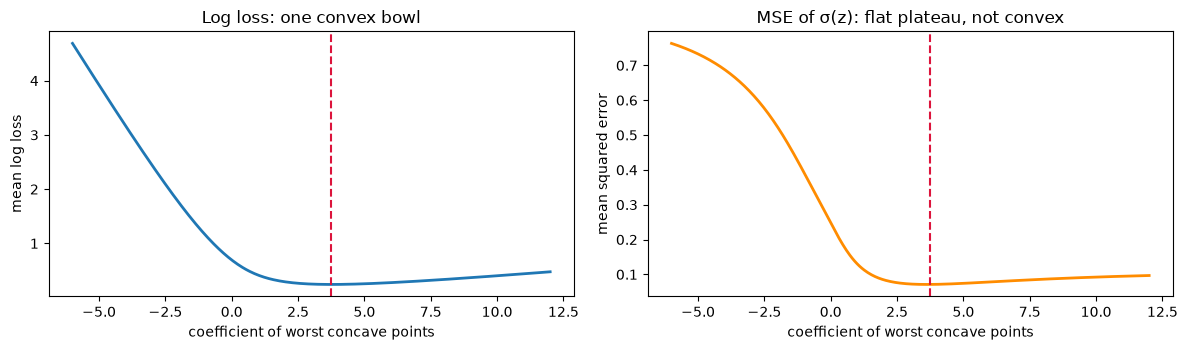

log loss has concave stretches: False | MSE has concave stretches: True


In [11]:
# (a) Log loss × n equals minus statsmodels' log-likelihood
three = ["worst concave points", "worst area", "worst texture"]
three_scaler = StandardScaler().fit(X_train[three])
Z3 = sm.add_constant(three_scaler.transform(X_train[three]))
mle_fit = sm.Logit(y_train.to_numpy(), Z3).fit(disp=0)
p3 = mle_fit.predict(Z3)
print(f"statsmodels log-likelihood {mle_fit.llf:.6f} | −n × log loss {-len(y_train) * log_loss(y_train, p3):.6f}")
hessian = Z3.T @ (Z3 * (p3 * (1 - p3))[:, None])
print(f"smallest eigenvalue of the Hessian XᵀSX: {np.linalg.eigvalsh(hessian).min():.3f} (≥ 0 → convex)")

# (b) One example with y = 1 that the model gets confidently wrong (z = -6)
z_wrong, y_one = -6.0, 1.0
p_wrong = expit(z_wrong)
print(f"\nconfidently wrong example (p = {p_wrong:.4f} for a true 1): gradient w.r.t. z → "
      f"log loss {p_wrong - y_one:+.4f} | MSE {2 * (p_wrong - y_one) * p_wrong * (1 - p_wrong):+.4f}")

# (c) The loss landscape along one coefficient on real data
x_wcp = StandardScaler().fit_transform(X_train[["worst concave points"]]).ravel()
one_feature = LogisticRegression(C=1e6, max_iter=5000).fit(x_wcp[:, None], y_train)
w_values = np.linspace(-6, 12, 400)
p_path = expit(one_feature.intercept_[0] + np.outer(w_values, x_wcp))
mean_log_loss = -np.mean(y_train.to_numpy() * np.log(np.clip(p_path, 1e-15, 1)) + (1 - y_train.to_numpy()) * np.log(np.clip(1 - p_path, 1e-15, 1)), axis=1)
mean_squared = np.mean((p_path - y_train.to_numpy()) ** 2, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].plot(w_values, mean_log_loss, lw=2)
axes[0].set(xlabel="coefficient of worst concave points", ylabel="mean log loss", title="Log loss: one convex bowl")
axes[1].plot(w_values, mean_squared, lw=2, color="darkorange")
axes[1].set(xlabel="coefficient of worst concave points", ylabel="mean squared error", title="MSE of σ(z): flat plateau, not convex")
for ax in axes:
    ax.axvline(one_feature.coef_[0, 0], ls="--", color="crimson")
plt.tight_layout()
plt.show()
print(f"log loss has concave stretches: {bool(np.any(np.diff(mean_log_loss, 2) < -1e-12))} | "
      f"MSE has concave stretches: {bool(np.any(np.diff(mean_squared, 2) < -1e-12))}")

### ✍️ Your Turn

Compute the **mean log loss** by hand for labels `y_small = [1, 0, 1]` and predicted probabilities `p_small = [0.9, 0.2, 0.6]`. Store it in `logloss_manual`.

In [12]:
y_small = np.array([1, 0, 1])
p_small = np.array([0.9, 0.2, 0.6])
logloss_manual = None  # TODO
check("logloss_manual", logloss_manual, log_loss(y_small, p_small), hint="-mean(y·log p + (1 − y)·log(1 − p))")

⏳ logloss_manual: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
y_small = np.array([1, 0, 1])
p_small = np.array([0.9, 0.2, 0.6])
logloss_manual = -np.mean(y_small * np.log(p_small) + (1 - y_small) * np.log(1 - p_small))
check("logloss_manual", logloss_manual, log_loss(y_small, p_small))
```

$(0.105 + 0.223 + 0.511)/3 \approx 0.280$. The 0.6 prediction for a true 1 costs more than the other two together.
</details>

> 💡 **Interview angle:** "Why log loss and not MSE for logistic regression?" — log loss is the negative Bernoulli log-likelihood (MLE), it is convex in β with Hessian $X^\top SX$, and its gradient $X^\top(p-y)$ stays large when the model is confidently wrong. MSE on sigmoid outputs is non-convex and its gradient vanishes ($\propto p(1-p)$) exactly when learning matters most.

## 5. Regularization: L2, L1, Elastic-Net, and C 🟡

scikit-learn's binary objective (note **C multiplies the loss**, so it is the *inverse* of the regularization strength):

$$\min_{w,\,b}\;\; C\sum_{i=1}^n \text{logloss}_i \;+\; \frac{1-\rho}{2}\lVert w\rVert_2^2 \;+\; \rho\,\lVert w\rVert_1, \qquad \rho = \texttt{l1\_ratio}$$

- **Small C → strong penalty** → smaller coefficients, simpler model. **Large C → weak penalty**. `C=np.inf` → no penalty.
- `l1_ratio=0` (the default) is **L2 (ridge)**, `l1_ratio=1` is **L1 (lasso)** with exact zeros, values in between are **elastic-net**.
- The intercept $b$ is not penalized (except by `liblinear`, which treats it like a weight).

⚠️ **API change (verified in 1.9):** the `penalty=` argument was **deprecated in 1.8** and will be removed in 1.10. Use `l1_ratio` and `C` instead. The `multi_class=` argument is already **gone**.

In [13]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    LogisticRegression(penalty="l1", solver="liblinear").fit(StandardScaler().fit_transform(X_train), y_train)
for w in caught:
    print(f"❌ penalty='l1' → {w.category.__name__}: {str(w.message).splitlines()[0][:110]}")
try:
    LogisticRegression(multi_class="ovr")
except TypeError as err:
    print(f"❌ multi_class='ovr' → TypeError: {err}")
print("✅ modern spelling: LogisticRegression(l1_ratio=1.0, solver='liblinear') for L1, LogisticRegression(C=np.inf) for no penalty")

❌ penalty='l1' → FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' se
❌ penalty='l1' → UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
❌ multi_class='ovr' → TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'
✅ modern spelling: LogisticRegression(l1_ratio=1.0, solver='liblinear') for L1, LogisticRegression(C=np.inf) for no penalty


convergence warnings while computing the paths: 0


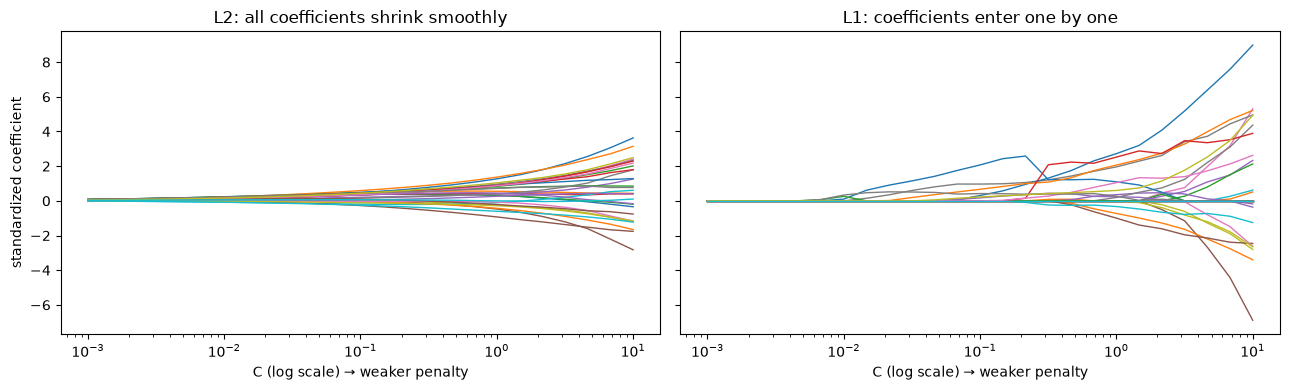

C≈0.01 : non-zero coefficients L2 30 | L1  3 of 30
C≈0.1  : non-zero coefficients L2 30 | L1  7 of 30
C≈1.0  : non-zero coefficients L2 30 | L1 14 of 30


In [14]:
scaler_bc = StandardScaler().fit(X_train)
Z_train, Z_val = scaler_bc.transform(X_train), scaler_bc.transform(X_val)
path_Cs = np.logspace(-3, 1, 25)
with warnings.catch_warnings(record=True) as path_warnings:
    warnings.simplefilter("always", ConvergenceWarning)
    l2_path = np.array([LogisticRegression(C=c, max_iter=10_000).fit(Z_train, y_train).coef_[0] for c in path_Cs])
    l1_path = np.array([LogisticRegression(C=c, l1_ratio=1.0, solver="liblinear", max_iter=10_000).fit(Z_train, y_train).coef_[0] for c in path_Cs])
print(f"convergence warnings while computing the paths: {len(path_warnings)}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
axes[0].plot(path_Cs, l2_path, lw=1)
axes[0].set(xscale="log", xlabel="C (log scale) → weaker penalty", ylabel="standardized coefficient", title="L2: all coefficients shrink smoothly")
axes[1].plot(path_Cs, l1_path, lw=1)
axes[1].set(xscale="log", xlabel="C (log scale) → weaker penalty", title="L1: coefficients enter one by one")
plt.tight_layout()
plt.show()
for c in [0.01, 0.1, 1.0]:
    j = np.argmin(np.abs(path_Cs - c))
    print(f"C≈{c:<5}: non-zero coefficients L2 {int(np.sum(l2_path[j] != 0)):>2} | L1 {int(np.sum(l1_path[j] != 0)):>2} of {Z_train.shape[1]}")

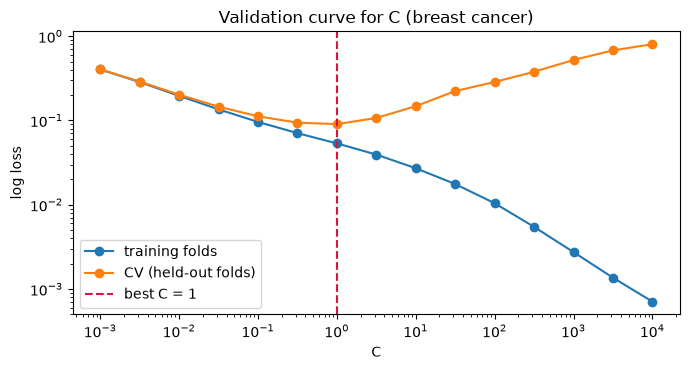

best CV log loss 0.0904 at C = 1 | C = 1 (default): 0.0904 | C = 1e+04: 0.8024 (training 0.0007) → weak regularization overfits


In [15]:
# Hyperparameter experiment: the validation curve for C (the scaler is refit inside every fold)
curve_Cs = np.logspace(-3, 4, 15)
train_scores, cv_scores = validation_curve(make_pipeline(StandardScaler(), LogisticRegression(max_iter=10_000)), X_train, y_train,
                                           param_name="logisticregression__C", param_range=curve_Cs, cv=cv5, scoring="neg_log_loss")
train_ll, cv_ll = -train_scores.mean(axis=1), -cv_scores.mean(axis=1)
best_c = curve_Cs[np.argmin(cv_ll)]
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(curve_Cs, train_ll, marker="o", label="training folds")
ax.plot(curve_Cs, cv_ll, marker="o", label="CV (held-out folds)")
ax.axvline(best_c, ls="--", color="crimson", label=f"best C = {best_c:.3g}")
ax.set(xscale="log", yscale="log", xlabel="C", ylabel="log loss", title="Validation curve for C (breast cancer)")
ax.legend()
plt.tight_layout()
plt.show()
print(f"best CV log loss {cv_ll.min():.4f} at C = {best_c:.3g} | C = 1 (default): {cv_ll[np.argmin(np.abs(curve_Cs - 1))]:.4f} | "
      f"C = {curve_Cs[-1]:.0e}: {cv_ll[-1]:.4f} (training {train_ll[-1]:.4f}) → weak regularization overfits")

### ✍️ Your Turn

[ML Fundamentals](01_ML_Fundamentals_From_Scratch.ipynb) minimized the **mean** log loss plus $\frac{\lambda}{2}\lVert w\rVert^2$. Dividing scikit-learn's objective by $Cn$ shows the two are identical when $C = 1/(\lambda n)$. For $\lambda = 0.01$ and our training set, compute the equivalent `C`. Store it in `c_equivalent`.

In [16]:
lam = 0.01
c_equivalent = None  # TODO
check("c_equivalent", c_equivalent, 1 / (0.01 * 426), hint="1 / (lam * len(y_train))")

⏳ c_equivalent: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
lam = 0.01
c_equivalent = 1 / (lam * len(y_train))
check("c_equivalent", c_equivalent, 1 / (0.01 * 426))
```

Because C multiplies a **sum** over rows, the same C means weaker regularization on a bigger dataset. Re-tune C when the training set size changes a lot.
</details>

> 💡 **Interview angle:** "What is C in LogisticRegression?" — the inverse regularization strength multiplying the summed log loss: small C = strong penalty. `l1_ratio` picks L2 (0), L1 (1) or elastic-net. In scikit-learn ≥ 1.8, `penalty=` is deprecated, so say "l1_ratio and C". Tune C on a log grid with cross-validated log loss, and remember that regularization is also what keeps coefficients finite on separable data.

## 6. Solvers and Why Scaling Matters 🟡

The objective is convex, but solvers differ in which penalties they support, how they scale, and how sensitive they are to feature scale. Instead of trusting a table from memory, we **ask the installed version**: we try every solver with every penalty and on a 3-class problem.

In [17]:
wine = load_wine(as_frame=True)
X_wine, y_wine = wine.data, wine.target
Z_wine = StandardScaler().fit_transform(X_wine)
solvers = ["lbfgs", "liblinear", "newton-cg", "newton-cholesky", "sag", "saga"]
settings = {"L2 (l1_ratio=0)": (dict(l1_ratio=0.0), Z_train, y_train), "L1 (l1_ratio=1)": (dict(l1_ratio=1.0), Z_train, y_train),
            "elastic-net (0.5)": (dict(l1_ratio=0.5), Z_train, y_train), "no penalty (C=inf)": (dict(C=np.inf), Z_train, y_train),
            "3 classes (wine)": ({}, Z_wine, y_wine)}
support = pd.DataFrame(index=solvers, columns=list(settings), dtype=object)
for solver in solvers:
    for label, (kwargs, X_, y_) in settings.items():
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ConvergenceWarning)      # here we only ask "is it supported?"
            try:
                LogisticRegression(solver=solver, max_iter=2000, **kwargs).fit(X_, y_)
                support.loc[solver, label] = "✅"
            except ValueError:
                support.loc[solver, label] = "❌"
print(support.to_string())

                L2 (l1_ratio=0) L1 (l1_ratio=1) elastic-net (0.5) no penalty (C=inf) 3 classes (wine)
lbfgs                         ✅               ❌                 ❌                  ✅                ✅
liblinear                     ✅               ✅                 ❌                  ❌                ❌
newton-cg                     ✅               ❌                 ❌                  ✅                ✅
newton-cholesky               ✅               ❌                 ❌                  ✅                ✅
sag                           ✅               ❌                 ❌                  ✅                ✅
saga                          ✅               ✅                 ✅                  ✅                ✅


**Choosing a solver:** `lbfgs` (default) is a good general choice for L2. Use `liblinear` for small binary L1 problems, `newton-cholesky` when $n \gg p$ (e.g. one-hot features with few columns: very few iterations), and `saga` for elastic-net or very large sparse data.

**Why scaling matters.** Features on wildly different scales (breast-cancer areas are in the hundreds, smoothness values around 0.1) create a long, narrow valley in the loss. First-order solvers zig-zag down such a valley. Standardizing makes it round.

In [18]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    LogisticRegression().fit(X_train, y_train)                    # unscaled, default max_iter=100
print("❌ unscaled + defaults:", [f"{w.category.__name__}: {str(w.message).splitlines()[0]}" for w in caught])

scaling_rows = []
for solver in ["lbfgs", "liblinear", "newton-cholesky", "saga"]:
    for scaled in [False, True]:
        estimator = LogisticRegression(solver=solver, max_iter=20_000, tol=1e-6)
        model = make_pipeline(StandardScaler(), estimator) if scaled else estimator
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always", ConvergenceWarning)
            start = time.perf_counter()
            model.fit(X_train, y_train)
            seconds = time.perf_counter() - start
        scaling_rows.append({"solver": solver, "features": "standardized" if scaled else "raw",
                             "iterations": int(np.max(estimator.n_iter_)), "seconds": seconds,
                             "converged": not any(issubclass(w.category, ConvergenceWarning) for w in caught),
                             "val log loss": log_loss(y_val, model.predict_proba(X_val)[:, 1])})
scaling_table = pd.DataFrame(scaling_rows).set_index(["solver", "features"])
print(scaling_table.to_string(float_format=lambda v: f"{v:.4f}"))
speedups = (scaling_table.xs("raw", level="features")["iterations"] / scaling_table.xs("standardized", level="features")["iterations"]).round(1)
print("\niterations(raw) / iterations(standardized):", speedups.to_dict())

❌ unscaled + defaults: ['ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):']


                              iterations  seconds  converged  val log loss
solver          features                                                  
lbfgs           raw                 4584   0.1497       True        0.1055
                standardized          33   0.0021       True        0.0776
liblinear       raw                   26   0.0019       True        0.1096
                standardized          10   0.0018       True        0.0770
newton-cholesky raw                    9   0.0012       True        0.1055
                standardized           8   0.0015       True        0.0776
saga            raw                20000   0.8216      False        0.1872
                standardized        1204   0.0506       True        0.0776

iterations(raw) / iterations(standardized): {'lbfgs': 138.9, 'liblinear': 2.6, 'newton-cholesky': 1.1, 'saga': 16.6}


Scaling cut the iteration count for every iterative solver, most dramatically for first-order methods (`lbfgs`, `saga`). The raw `saga` run may not even converge. Also note that with regularization the **fitted model itself** depends on scaling, because the penalty treats all coefficients equally, so validation log loss changes too.

### ✍️ Your Turn

From the `support` table (don't type the answer by hand), build the list of solvers that support **elastic-net**. Store it in `elasticnet_solvers`.

In [19]:
elasticnet_solvers = None  # TODO
check("elasticnet_solvers", elasticnet_solvers, ["saga"], hint="support.index[support['elastic-net (0.5)'] == '✅'].tolist()")

⏳ elasticnet_solvers: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
elasticnet_solvers = support.index[support["elastic-net (0.5)"] == "✅"].tolist()
check("elasticnet_solvers", elasticnet_solvers, ["saga"])
```

Only `saga` handles every penalty (and multiclass). The price: it's a stochastic first-order method, so it's the most sensitive to scaling and `max_iter`.
</details>

> 💡 **Interview angle:** "Your LogisticRegression throws a ConvergenceWarning. What do you do?" — standardize the features first (usually the real fix), then raise `max_iter`, try a second-order solver (`newton-cholesky` when n ≫ p), or add regularization (smaller C). If coefficients keep growing, suspect perfect separation. Don't silence the warning.

## 7. Multiclass: One-vs-Rest vs Multinomial (Softmax) 🟡

Two ways to go beyond two classes:

| | **One-vs-Rest (OvR)** | **Multinomial (softmax)** |
|---|---|---|
| Models | K separate binary logistic regressions ("class k vs everything else") | one joint model with K score vectors |
| Probabilities | K sigmoids, renormalized to sum to 1 | $p_k = \dfrac{e^{z_k}}{\sum_j e^{z_j}}$, sums to 1 by construction |
| Loss | K binary log losses | one cross-entropy $-\sum_i \log p_{i,y_i}$ |
| In scikit-learn 1.9 | `OneVsRestClassifier(LogisticRegression())` | `LogisticRegression()`: every solver except `liblinear` |
| Pros | parallel, works with any binary classifier | better calibrated probabilities; the "right" model when classes are exclusive |

Softmax is the generalization of the sigmoid: with K = 2 it reduces exactly to logistic regression on $z_1 - z_0$.

In [20]:
multiclass_rows = []
multi_models = {"multinomial (softmax)": LogisticRegression(max_iter=5000),
                "one-vs-rest": OneVsRestClassifier(LogisticRegression(max_iter=5000))}
for name, estimator in multi_models.items():
    for features_label, cols in [("2 features", ["flavanoids", "proline"]), ("all 13 features", list(X_wine.columns))]:
        scores = cross_validate(make_pipeline(StandardScaler(), estimator), X_wine[cols], y_wine, cv=cv5, scoring=["accuracy", "neg_log_loss"])
        multiclass_rows.append({"model": name, "features": features_label, "CV accuracy": scores["test_accuracy"].mean(),
                                "CV log loss": -scores["test_neg_log_loss"].mean()})
multiclass_table = pd.DataFrame(multiclass_rows).set_index(["features", "model"]).sort_index()
print(multiclass_table.round(4).to_string())
for features_label in ["2 features", "all 13 features"]:
    sub = multiclass_table.loc[features_label, "CV log loss"]
    print(f"{features_label}: lower (better) log loss → {sub.idxmin()}")

                                       CV accuracy  CV log loss
features        model                                          
2 features      multinomial (softmax)       0.8925       0.2716
                one-vs-rest                 0.9037       0.3206
all 13 features multinomial (softmax)       0.9833       0.0611
                one-vs-rest                 0.9833       0.0796
2 features: lower (better) log loss → multinomial (softmax)
all 13 features: lower (better) log loss → multinomial (softmax)


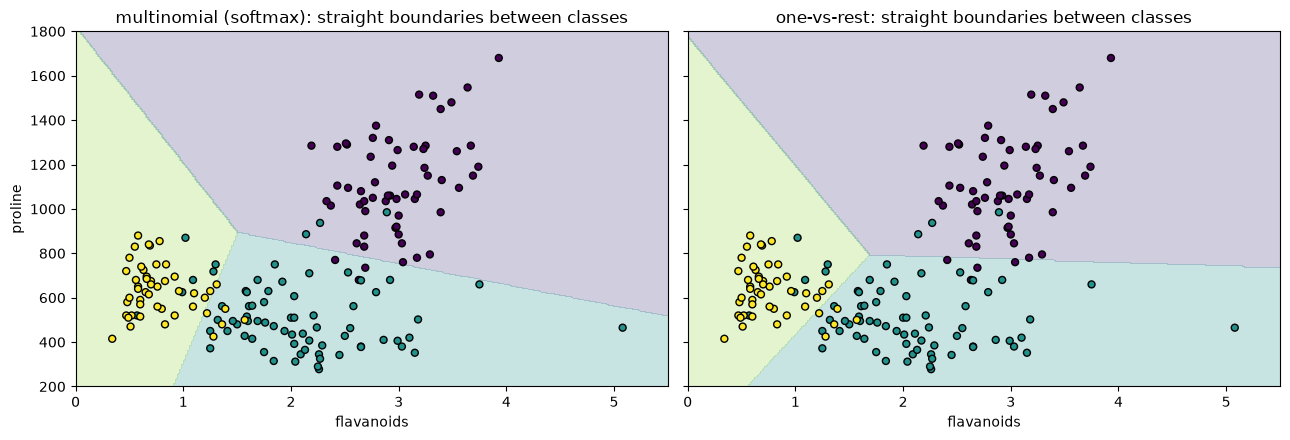

OvR raw sigmoid outputs summed per row: min 0.517, max 1.632 → renormalized by predict_proba
softmax probabilities summed per row: all equal 1 → True


In [21]:
two_wine = ["flavanoids", "proline"]
fitted_multi = {name: make_pipeline(StandardScaler(), est).fit(X_wine[two_wine], y_wine) for name, est in multi_models.items()}
f_grid, p_grid = np.meshgrid(np.linspace(0, 5.5, 300), np.linspace(200, 1800, 300))
grid_frame = pd.DataFrame({"flavanoids": f_grid.ravel(), "proline": p_grid.ravel()})
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, (name, model) in zip(axes, fitted_multi.items()):
    regions = model.predict(grid_frame).reshape(f_grid.shape)
    ax.contourf(f_grid, p_grid, regions, levels=[-0.5, 0.5, 1.5, 2.5], cmap="viridis", alpha=0.25)
    ax.scatter(X_wine["flavanoids"], X_wine["proline"], c=y_wine, cmap="viridis", edgecolor="k", s=25)
    ax.set(xlabel="flavanoids", title=f"{name}: straight boundaries between classes")
axes[0].set_ylabel("proline")
plt.tight_layout()
plt.show()

ovr_model = fitted_multi["one-vs-rest"]
raw_sigmoids = np.column_stack([est.predict_proba(ovr_model[0].transform(X_wine[two_wine]))[:, 1] for est in ovr_model[-1].estimators_])
print(f"OvR raw sigmoid outputs summed per row: min {raw_sigmoids.sum(axis=1).min():.3f}, max {raw_sigmoids.sum(axis=1).max():.3f} → renormalized by predict_proba")
print(f"softmax probabilities summed per row: all equal 1 → {np.allclose(fitted_multi['multinomial (softmax)'].predict_proba(X_wine[two_wine]).sum(axis=1), 1)}")

### ✍️ Your Turn

Implement a **numerically stable softmax** for the logits `[1000, 1001, 1002]` (the naive `np.exp` overflows). Hint: subtracting the same number from every logit doesn't change the result. Store the probabilities in `stable_probs`.

In [22]:
logits_big = np.array([1000.0, 1001.0, 1002.0])
stable_probs = None  # TODO
check("stable_probs", stable_probs, softmax(logits_big), hint="shifted = logits - logits.max(); np.exp(shifted) / np.exp(shifted).sum()")

⏳ stable_probs: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
logits_big = np.array([1000.0, 1001.0, 1002.0])
shifted = logits_big - logits_big.max()          # largest logit becomes 0 → no overflow
stable_probs = np.exp(shifted) / np.exp(shifted).sum()
check("stable_probs", stable_probs, softmax(logits_big))
print(stable_probs)
```

$[0.090, 0.245, 0.665]$: only the *differences* between logits matter, which is also why one class's coefficients in a multinomial model are only identified up to a shared shift (regularization pins them down).
</details>

> 💡 **Interview angle:** "One-vs-rest or softmax?" — for mutually exclusive classes, multinomial/softmax optimizes one joint likelihood and gives coherent probabilities (here it had the lower log loss with all features). OvR trains K independent binary models whose sigmoids don't sum to 1; it's handy for any binary learner, parallel training, or multi-label problems. In scikit-learn ≥ 1.8 `LogisticRegression` is multinomial by default; wrap it in `OneVsRestClassifier` for OvR.

## 8. Coefficients as Odds Ratios With statsmodels 🟡

For **explanation** we want each coefficient with a standard error, a p-value and a confidence interval, and we want them on the **odds-ratio** scale:

$$\text{OR}_j = e^{\beta_j}, \qquad 95\%\ \text{CI} = \big(e^{\beta_j - 1.96\,\text{SE}_j},\; e^{\beta_j + 1.96\,\text{SE}_j}\big)$$

- OR = 1: no association. OR > 1: higher odds. OR < 1: lower odds. A CI that excludes 1 ↔ p < 0.05.
- For a continuous feature, the OR for a $k$-unit change is $e^{k\beta_j}$ (e.g. per 10 years of age).
- Odds ratios are **not** risk ratios, and not probability changes. For "percentage points of probability", use **average marginal effects** (`get_margeff`).

We use the **Titanic** passenger list (OpenML) and model survival.

In [23]:
titanic = fetch_openml(name="titanic", version=1, as_frame=True, data_home=DATA_DIR).frame
titanic["survived"] = titanic["survived"].astype(int)
print(titanic[["survived", "pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]].head(4).to_string())
print(f"\n{len(titanic):,} passengers | survival rate {titanic['survived'].mean():.1%} | missing age: {titanic['age'].isna().sum()}")

titanic_fit = smf.logit("survived ~ C(sex) + C(pclass) + age + sibsp + parch + fare", data=titanic).fit(disp=0)
ci = titanic_fit.conf_int()
or_table = pd.DataFrame({"coef (log-odds)": titanic_fit.params, "odds ratio": np.exp(titanic_fit.params),
                         "OR 2.5%": np.exp(ci[0]), "OR 97.5%": np.exp(ci[1]), "p-value": titanic_fit.pvalues})
print(f"rows used: {int(titanic_fit.nobs)} of {len(titanic)} (statsmodels silently drops rows with missing age/fare)")
print(or_table.to_string(float_format=lambda v: f"{v:.4g}"))

or_male, lo_male, hi_male = or_table.loc["C(sex)[T.male]", ["odds ratio", "OR 2.5%", "OR 97.5%"]]
age_or10 = np.exp(10 * titanic_fit.params["age"])
age_ci10 = np.exp(10 * ci.loc["age"])
print(f"\n→ Holding class, age and family size fixed, men had {or_male:.3f}× the odds of survival of women (95% CI {lo_male:.3f}–{hi_male:.3f}).")
print(f"→ Each extra 10 years of age multiplied the odds of survival by {age_or10:.3f} (95% CI {age_ci10[0]:.3f}–{age_ci10[1]:.3f}).")
insignificant = or_table.index[(or_table["p-value"] >= 0.05) & (or_table.index != "Intercept")].tolist()
print(f"→ Not significant at 5% once the others are included: {insignificant}")

   survived  pclass     sex      age  sibsp  parch      fare embarked
0         1       1  female  29.0000      0      0  211.3375        S
1         1       1    male   0.9167      1      2  151.5500        S
2         0       1  female   2.0000      1      2  151.5500        S
3         0       1    male  30.0000      1      2  151.5500        S

1,309 passengers | survival rate 38.2% | missing age: 263
rows used: 1045 of 1309 (statsmodels silently drops rows with missing age/fare)
                coef (log-odds)  odds ratio  OR 2.5%  OR 97.5%   p-value
Intercept                   3.8        44.7    20.52      97.4 1.144e-21
C(sex)[T.male]           -2.552     0.07796  0.05548    0.1095 6.132e-49
C(pclass)[T.2]           -1.289      0.2756   0.1654    0.4592 7.518e-07
C(pclass)[T.3]           -2.258      0.1046  0.06139    0.1782 1.022e-16
age                    -0.03922      0.9615   0.9491    0.9741 3.588e-09
sibsp                   -0.3589      0.6985   0.5676    0.8596 0.0007029


In [24]:
margeff = titanic_fit.get_margeff(at="overall").summary_frame()
print("average marginal effects (change in survival PROBABILITY):")
print(margeff.iloc[:, [0, 1, 4, 5]].round(4).to_string())
print(f"\n→ Being male lowered the survival probability by {abs(margeff.iloc[0, 0]):.1%} points on average, "
      f"a far more intuitive number for a stakeholder than an odds ratio of {or_male:.3f}.")

# Same model in scikit-learn: reference-coded dummies + no penalty (C=np.inf)
titanic_rows = titanic.dropna(subset=["age", "fare"])
X_titanic_design = pd.get_dummies(titanic_rows[["age", "sibsp", "parch", "fare", "sex", "pclass"]].astype({"pclass": "category"}),
                                  columns=["sex", "pclass"], drop_first=True, dtype=float)
y_titanic = titanic_rows["survived"]
sk_titanic = LogisticRegression(C=np.inf, solver="newton-cholesky", max_iter=1000, tol=1e-10).fit(X_titanic_design, y_titanic)
name_map = {"age": "age", "sibsp": "sibsp", "parch": "parch", "fare": "fare", "sex_male": "C(sex)[T.male]",
            "pclass_2": "C(pclass)[T.2]", "pclass_3": "C(pclass)[T.3]"}
sm_coefs = titanic_fit.params[[name_map[c] for c in X_titanic_design.columns]].to_numpy()
assert np.allclose(sk_titanic.coef_[0], sm_coefs, rtol=1e-4, atol=1e-5)
assert np.isclose(sk_titanic.intercept_[0], titanic_fit.params["Intercept"], rtol=1e-4)
print("✅ LogisticRegression(C=np.inf) reproduces the statsmodels coefficients (statsmodels adds SEs, CIs and p-values)")

average marginal effects (change in survival PROBABILITY):
                 dy/dx  Std. Err.  Conf. Int. Low  Cont. Int. Hi.
C(sex)[T.male] -0.3809     0.0140         -0.4084         -0.3535
C(pclass)[T.2] -0.1924     0.0375         -0.2659         -0.1189
C(pclass)[T.3] -0.3370     0.0366         -0.4087         -0.2654
age            -0.0059     0.0009         -0.0077         -0.0040
sibsp          -0.0536     0.0155         -0.0840         -0.0231
parch           0.0087     0.0154         -0.0214          0.0389
fare            0.0002     0.0003         -0.0004          0.0007

→ Being male lowered the survival probability by 38.1% points on average, a far more intuitive number for a stakeholder than an odds ratio of 0.078.
✅ LogisticRegression(C=np.inf) reproduces the statsmodels coefficients (statsmodels adds SEs, CIs and p-values)


### ✍️ Your Turn

Using `titanic_fit`, compute the **odds ratio for 5 extra siblings/spouses aboard** (`sibsp` + 5). Store it in `or_sibsp_5`.

In [25]:
or_sibsp_5 = None  # TODO
check("or_sibsp_5", or_sibsp_5, np.exp(5 * titanic_fit.params["sibsp"]), hint="np.exp(5 * coefficient)")

⏳ or_sibsp_5: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
or_sibsp_5 = np.exp(5 * titanic_fit.params["sibsp"])
check("or_sibsp_5", or_sibsp_5, np.exp(5 * titanic_fit.params["sibsp"]))
print(f"odds multiplied by {or_sibsp_5:.3f}")
```

Odds ratios **multiply**: $e^{5\beta} = (e^{\beta})^5$. Five times a 0.70 odds ratio is not "5 × 0.70", it's $0.70^5 \approx 0.17$.
</details>

> 💡 **Interview angle:** "How do you interpret a logistic regression coefficient for a stakeholder?" — exponentiate it: "holding the other features fixed, men had 0.08× the odds of survival of women (95% CI …)". Then translate to probabilities with average marginal effects ("about 38 percentage points lower"), and never call an odds ratio a risk ratio or a causal effect.

## 9. Assumptions, Perfect Separation, and Quasi-Separation 🔴

| Assumption | Plain English | If it breaks… | How to check | Fix |
|---|---|---|---|---|
| **Linear log-odds** | each feature's effect is a straight line on the logit scale | biased probabilities in some ranges | binned empirical log-odds vs feature (Section 13) | splines, polynomials, binning |
| **Independent observations** | one row doesn't inform another | standard errors too small | study design (repeated customers, clusters) | cluster-robust SEs, mixed models |
| **No perfect separation** | no feature combination splits the classes perfectly | the maximum-likelihood estimate **doesn't exist**: coefficients run to ±∞ | 100% training accuracy, huge coefficients/SEs, warnings | regularization, Firth's penalized likelihood, remove leaking features |
| **Low multicollinearity** | features aren't near copies | unstable coefficients, wide CIs | VIF, correlations | drop/combine features, L2 |
| **Enough events** | enough rows of the rarer class per parameter (rule of thumb ≥ 10–20) | overfitting, biased coefficients | count events per parameter | fewer features, regularization |

**Not** required: normally distributed errors, constant variance, or normally distributed features.

**Perfect separation** is the famous trap. If some hyperplane puts every positive on one side and every negative on the other, you can always lower the log loss by **scaling the coefficients up**: the probabilities get closer to exactly 0 and 1, and the loss never reaches its minimum. The unpenalized MLE is infinite.

**Experiment 1:** the 30 breast-cancer features (standardized) nearly or fully separate the training tumours. Watch the coefficients as regularization weakens.

In [26]:
separation_rows = []
for c in [1.0, 1e2, 1e4, 1e8]:
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always", ConvergenceWarning)
        sep_model = LogisticRegression(C=c, max_iter=100_000, tol=1e-10).fit(Z_train, y_train)
    separation_rows.append({"C": c, "training accuracy": accuracy_score(y_train, sep_model.predict(Z_train)),
                            "‖w‖₂": np.linalg.norm(sep_model.coef_), "iterations": int(sep_model.n_iter_[0]),
                            "validation log loss": log_loss(y_val, sep_model.predict_proba(Z_val)[:, 1]),
                            "validation accuracy": accuracy_score(y_val, sep_model.predict(Z_val)),
                            "warnings": len(caught)})
separation_table = pd.DataFrame(separation_rows).set_index("C")
print(separation_table.to_string(float_format=lambda v: f"{v:.4g}"))
separable = bool((separation_table["training accuracy"] == 1.0).any())
print(f"\n→ training data perfectly separated at weak regularization: {separable}. As C grows, ‖w‖ explodes and validation log loss gets "
      f"{separation_table['validation log loss'].iloc[-1] / separation_table['validation log loss'].iloc[0]:.0f}× worse: the model becomes absurdly overconfident.")

            training accuracy  ‖w‖₂  iterations  validation log loss  validation accuracy  warnings
C                                                                                                  
1.0000e+00             0.9883 3.764          46              0.07756                0.965         0
1.0000e+02             0.9953 24.46         206                0.402               0.9371         0
1.0000e+04                  1 111.1         535                1.434               0.9301         0
1.0000e+08                  1 340.9         568                2.254               0.9301         0

→ training data perfectly separated at weak regularization: True. As C grows, ‖w‖ explodes and validation log loss gets 29× worse: the model becomes absurdly overconfident.


In [27]:
# Experiment 2: the unpenalized maximum-likelihood fit in statsmodels on the same data
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    try:
        sep_mle = sm.Logit(y_train.to_numpy(), sm.add_constant(Z_train)).fit(disp=0, maxiter=200)
        print(f"statsmodels returned coefficients up to |β| = {np.abs(sep_mle.params).max():.3g}, "
              f"converged = {sep_mle.mle_retvals.get('converged')}, largest standard error {np.nanmax(sep_mle.bse):.3g}")
    except Exception as err:
        print(f"statsmodels could not fit the model: {type(err).__name__}: {str(err).splitlines()[0][:100]}")
warning_kinds = sorted({f"{w.category.__name__}: {str(w.message).splitlines()[0][:70]}" for w in caught})
print("warnings raised:", warning_kinds or "none")
print("→ Either way, the unpenalized coefficients are meaningless here; the regularized model (C=1) is the usable one.")

statsmodels returned coefficients up to |β| = 543, converged = False, largest standard error 5.32e+08
warnings raised: ['ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals', 'RuntimeWarning: overflow encountered in exp']
→ Either way, the unpenalized coefficients are meaningless here; the regularized model (C=1) is the usable one.


**Experiment 3 — quasi-separation from a leaking feature.** In the Titanic data, `boat` records the lifeboat a passenger escaped in. It is known only **after** the outcome.

In [28]:
titanic["has_boat"] = titanic["boat"].notna().astype(int)
print(pd.crosstab(titanic["has_boat"], titanic["survived"], margins=True).to_string())
boat_fit = smf.logit("survived ~ has_boat + C(sex)", data=titanic).fit(disp=0)
boat_or = np.exp(boat_fit.params["has_boat"])
boat_ci = np.exp(boat_fit.conf_int().loc["has_boat"])
print(f"\nodds ratio for having a boat: {boat_or:,.0f} (95% CI {boat_ci[0]:,.0f} – {boat_ci[1]:,.0f})")
print("→ Almost perfect separation: an enormous, uninformative odds ratio. The real problem is leakage, and ⚠️ Pitfall 4 shows what it does to CV scores.")

survived    0    1   All
has_boat                
0         800   23   823
1           9  477   486
All       809  500  1309

odds ratio for having a boat: 4,799 (95% CI 1,340 – 17,187)
→ Almost perfect separation: an enormous, uninformative odds ratio. The real problem is leakage, and ⚠️ Pitfall 4 shows what it does to CV scores.


> 💡 **Interview angle:** "What happens to logistic regression on perfectly separable data?" — the MLE doesn't exist: the likelihood keeps improving as $\lVert w\rVert \to \infty$, so coefficients and standard errors blow up and solvers stop at arbitrary huge values with overconfident probabilities. Fixes: L2 regularization (scikit-learn's default C=1), Firth's penalized likelihood for inference, or removing the leaking or ultra-rare feature that causes it.

## 10. Class Imbalance and class_weight 🟡

The **mammography** dataset has 11,183 suspicious regions from mammograms. Only **2.3%** are cancerous. (Its 6 features are anonymized image measurements.) We split **70% train / 30% validation**, stratified, and use it for Sections 10–12.

`class_weight="balanced"` multiplies each row's loss by $w_c = \dfrac{n}{K \cdot n_c}$, so both classes contribute equally to the total loss. What does it really change?

In [29]:
mammo = fetch_openml("mammography", version=1, as_frame=True, data_home=DATA_DIR)
X_mammo = mammo.data.astype(float)
y_mammo = (mammo.target.astype(str) == "1").astype(int)
Xm_train, Xm_val, ym_train, ym_val = train_test_split(X_mammo, y_mammo, test_size=0.3, stratify=y_mammo, random_state=SEED)
print(f"mammography: train {Xm_train.shape} · validation {Xm_val.shape} | positive rate {y_mammo.mean():.2%} "
      f"({int(ym_train.sum())} positives in training)")

mammo_models = {"unweighted": make_pipeline(StandardScaler(), LogisticRegression()).fit(Xm_train, ym_train),
                "class_weight='balanced'": make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced")).fit(Xm_train, ym_train)}
imbalance_rows = []
for name, model in mammo_models.items():
    proba = model.predict_proba(Xm_val)[:, 1]
    pred = (proba >= 0.5).astype(int)
    imbalance_rows.append({"model": name, "ROC-AUC": roc_auc_score(ym_val, proba), "PR-AUC": average_precision_score(ym_val, proba),
                           "recall@0.5": recall_score(ym_val, pred), "precision@0.5": precision_score(ym_val, pred, zero_division=0),
                           "flagged@0.5": pred.mean(), "mean predicted p": proba.mean(), "Brier": brier_score_loss(ym_val, proba),
                           "log loss": log_loss(ym_val, proba)})
imbalance_table = pd.DataFrame(imbalance_rows).set_index("model")
print(imbalance_table.round(4).to_string())
print(f"actual positive rate in validation: {ym_val.mean():.4f}")

intercept_shift = mammo_models["class_weight='balanced'"][-1].intercept_[0] - mammo_models["unweighted"][-1].intercept_[0]
prior_log_ratio = np.log((ym_train == 0).sum() / (ym_train == 1).sum())
delta = imbalance_table.iloc[1] - imbalance_table.iloc[0]
print(f"\n→ Weighting raised recall@0.5 by {delta['recall@0.5']:+.2f} and cut precision@0.5 by {delta['precision@0.5']:+.2f}, "
      f"but ROC-AUC changed by only {delta['ROC-AUC']:+.4f}: the ranking is almost the same.")
print(f"→ The intercept moved by {intercept_shift:+.2f}, close to log(n₀/n₁) = {prior_log_ratio:.2f}: weighting mostly shifts every score up, "
      f"so the mean predicted probability jumps from {imbalance_table.iloc[0]['mean predicted p']:.3f} to {imbalance_table.iloc[1]['mean predicted p']:.3f}.")

mammography: train (7828, 6) · validation (3355, 6) | positive rate 2.32% (182 positives in training)


                         ROC-AUC  PR-AUC  recall@0.5  precision@0.5  flagged@0.5  mean predicted p   Brier  log loss
model                                                                                                               
unweighted                0.9619  0.6504      0.3846         0.7895       0.0113            0.0225  0.0131    0.0507
class_weight='balanced'   0.9498  0.5546      0.8846         0.1774       0.1159            0.2282  0.0846    0.3070
actual positive rate in validation: 0.0232

→ Weighting raised recall@0.5 by +0.50 and cut precision@0.5 by -0.61, but ROC-AUC changed by only -0.0120: the ranking is almost the same.
→ The intercept moved by +3.97, close to log(n₀/n₁) = 3.74: weighting mostly shifts every score up, so the mean predicted probability jumps from 0.023 to 0.228.


**Lesson:** `class_weight` is mostly a **threshold shift in disguise** that also damages probability calibration (Brier and log loss got much worse). Often the cleaner recipe is: keep the model unweighted, then **choose the threshold** for the costs you care about (Section 11). Weighting can still help when the model is misspecified or heavily regularized, so compare both on validation.

### ✍️ Your Turn

Compute the `"balanced"` class weights for `ym_train` **with the formula** $n/(K \cdot n_c)$ as an array `[w_0, w_1]`. Store it in `balanced_weights`.

In [30]:
balanced_weights = None  # TODO
check("balanced_weights", balanced_weights, compute_class_weight("balanced", classes=np.array([0, 1]), y=ym_train),
      hint="len(y) / (2 * np.bincount(y))")

⏳ balanced_weights: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
balanced_weights = len(ym_train) / (2 * np.bincount(ym_train))
check("balanced_weights", balanced_weights, compute_class_weight("balanced", classes=np.array([0, 1]), y=ym_train))
print(balanced_weights)
```

Each positive counts about 43× as much as each negative ($w_1/w_0 = n_0/n_1$).
</details>

> 💡 **Interview angle:** "How do you handle a 2% positive rate with logistic regression?" — stratified splits, PR-AUC/recall-at-precision instead of accuracy, then either tune the **threshold** on validation for the real costs, or use `class_weight` and recalibrate. Mention that weighting (or resampling) shifts the intercept by about log(n₀/n₁), inflates predicted probabilities, and barely changes ROC-AUC.

## 11. Tuning the Decision Threshold on Validation Data 🟡

A threshold turns probabilities into actions, so it should come from the **costs of mistakes**, not from the number 0.5.

**Stated cost for this section:** in screening, missing a cancer (**false negative**) is assumed to cost **10×** as much as an unnecessary follow-up (**false positive**).

**Theory (for calibrated probabilities).** Flag a case when the expected cost of *not* flagging exceeds the cost of flagging: $p \cdot c_{FN} > (1-p) \cdot c_{FP}$, i.e.

$$p > t^* = \frac{c_{FP}}{c_{FP} + c_{FN}} = \frac{1}{11} \approx 0.091$$

**In practice** we pick the threshold that minimizes cost on data the model hasn't seen: **out-of-fold** predictions on the training set (5-fold `cross_val_predict`), or scikit-learn's `TunedThresholdClassifierCV`, which does the same internally. Then we evaluate once on the untouched validation split.

thresholds → cost-optimal (out-of-fold) 0.10 | TunedThresholdClassifierCV 0.101 | theory 1/11 = 0.091 | F1-optimal 0.26 | default 0.50


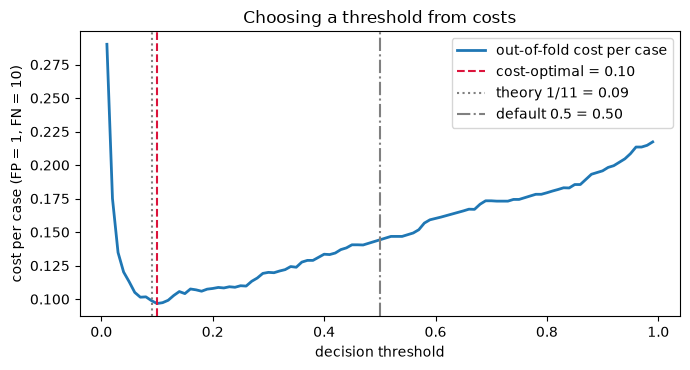

In [31]:
COST_FP, COST_FN = 1.0, 10.0


def cost_per_case(y_true, y_pred):
    """Average cost per screened case for hard 0/1 predictions."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return (COST_FP * fp + COST_FN * fn) / len(y_true)


oof_proba = cross_val_predict(make_pipeline(StandardScaler(), LogisticRegression()), Xm_train, ym_train, cv=cv5, method="predict_proba")[:, 1]
thresholds = np.linspace(0.01, 0.99, 99)
oof_costs = np.array([cost_per_case(ym_train, (oof_proba >= t).astype(int)) for t in thresholds])
oof_f1 = np.array([f1_score(ym_train, (oof_proba >= t).astype(int), zero_division=0) for t in thresholds])
t_cost_oof, t_f1_oof = thresholds[oof_costs.argmin()], thresholds[oof_f1.argmax()]
t_bayes = COST_FP / (COST_FP + COST_FN)

tuned = TunedThresholdClassifierCV(make_pipeline(StandardScaler(), LogisticRegression()),
                                   scoring=make_scorer(cost_per_case, greater_is_better=False), cv=cv5, random_state=SEED).fit(Xm_train, ym_train)
print(f"thresholds → cost-optimal (out-of-fold) {t_cost_oof:.2f} | TunedThresholdClassifierCV {tuned.best_threshold_:.3f} | "
      f"theory 1/11 = {t_bayes:.3f} | F1-optimal {t_f1_oof:.2f} | default 0.50")

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(thresholds, oof_costs, lw=2, label="out-of-fold cost per case")
for t, style, label in [(t_cost_oof, "--", "cost-optimal"), (t_bayes, ":", "theory 1/11"), (0.5, "-.", "default 0.5")]:
    ax.axvline(t, ls=style, color="crimson" if label == "cost-optimal" else "gray", label=f"{label} = {t:.2f}")
ax.set(xlabel="decision threshold", ylabel="cost per case (FP = 1, FN = 10)", title="Choosing a threshold from costs")
ax.legend()
plt.tight_layout()
plt.show()

In [32]:
val_proba = mammo_models["unweighted"].predict_proba(Xm_val)[:, 1]
threshold_rows = []
for label, t in [("default 0.5", 0.5), ("F1-optimal (OOF)", t_f1_oof), ("cost-optimal (OOF)", t_cost_oof),
                 ("TunedThresholdClassifierCV", tuned.best_threshold_), ("theory 1/11", t_bayes)]:
    pred = (val_proba >= t).astype(int)
    threshold_rows.append({"rule": label, "threshold": t, "cost per case": cost_per_case(ym_val, pred),
                           "recall": recall_score(ym_val, pred), "precision": precision_score(ym_val, pred, zero_division=0),
                           "flagged share": pred.mean()})
threshold_table = pd.DataFrame(threshold_rows).set_index("rule")
print(threshold_table.round(4).to_string())
best_rule = threshold_table["cost per case"].idxmin()
saving = 1 - threshold_table["cost per case"].min() / threshold_table.loc["default 0.5", "cost per case"]
print(f"\n→ On untouched validation data, '{best_rule}' has the lowest cost: {saving:.0%} cheaper than the default 0.5 threshold, "
      f"catching {threshold_table.loc[best_rule, 'recall']:.0%} of cancers instead of {threshold_table.loc['default 0.5', 'recall']:.0%}.")

                            threshold  cost per case  recall  precision  flagged share
rule                                                                                  
default 0.5                    0.5000         0.1455  0.3846     0.7895         0.0113
F1-optimal (OOF)               0.2600         0.1082  0.5641     0.6567         0.0200
cost-optimal (OOF)             0.1000         0.0829  0.7308     0.4560         0.0373
TunedThresholdClassifierCV     0.1010         0.0823  0.7308     0.4634         0.0367
theory 1/11                    0.0909         0.0829  0.7436     0.4265         0.0405

→ On untouched validation data, 'TunedThresholdClassifierCV' has the lowest cost: 43% cheaper than the default 0.5 threshold, catching 73% of cancers instead of 38%.


The threshold picked on out-of-fold data lands close to the theoretical $1/11$, because unweighted logistic regression is roughly calibrated. The F1-optimal threshold optimizes a different, implicit trade-off: **F1 has no notion of your costs**.

### ✍️ Your Turn

A fraud team says a missed fraud (FN) costs **\$200** and reviewing a legitimate transaction (FP) costs **\$5**. What probability threshold minimizes expected cost for a calibrated model? Store it in `fraud_threshold`.

In [33]:
fraud_threshold = None  # TODO
check("fraud_threshold", fraud_threshold, 5 / 205, hint="t* = c_FP / (c_FP + c_FN)")

⏳ fraud_threshold: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
fraud_threshold = 5 / (5 + 200)
check("fraud_threshold", fraud_threshold, 5 / 205)
print(f"flag when p > {fraud_threshold:.3f}")
```

About 0.024: review anything with more than a 2.4% fraud probability. If the model is **not** calibrated (e.g. trained with `class_weight`), this formula is wrong, so tune the threshold on validation data instead.
</details>

> 💡 **Interview angle:** "How do you choose the classification threshold?" — from the business costs: for calibrated probabilities $t^* = c_{FP}/(c_{FP}+c_{FN})$. In practice, minimize expected cost (or hit a recall/precision constraint) on out-of-fold or validation predictions, e.g. with `TunedThresholdClassifierCV`, then report the result once on the test set. Never tune the threshold on the test set.

## 12. Calibration: Can You Trust the Probabilities? 🟡

A model is **calibrated** if, among cases it scores 0.2, about 20% are positive. Calibration matters whenever the probability itself is used (expected-cost thresholds, pricing, risk communication).

- **Reliability diagram:** bin the predictions, plot the mean predicted probability vs the observed positive rate. Perfect calibration is the diagonal.
- **Brier score** = mean $(p - y)^2$; **log loss** also rewards calibration.
- Unweighted logistic regression is usually well calibrated because MLE matches predicted and observed rates overall (with an intercept, the mean training prediction equals the positive rate). **Class weights, resampling and strong regularization break this.**
- **Fix:** `CalibratedClassifierCV` with `method="sigmoid"` (Platt scaling) or `"isotonic"`, fitted on data the model hasn't trained on. For an already-fitted model, wrap it in `FrozenEstimator` and calibrate on a separate calibration split.

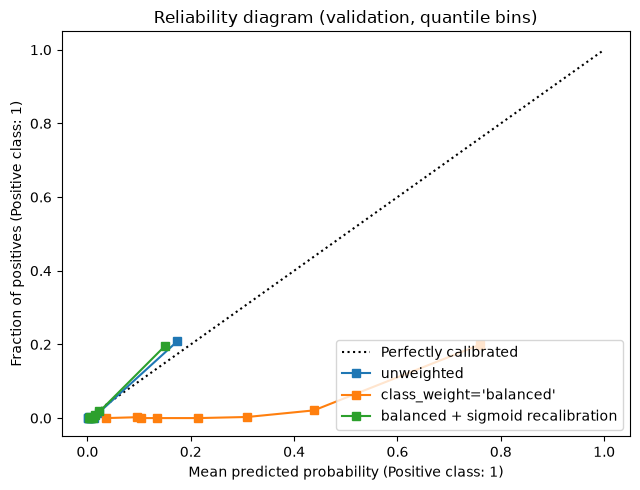

                                   Brier  log loss  mean predicted p  ROC-AUC
model                                                                        
unweighted                        0.0131    0.0507            0.0225   0.9619
class_weight='balanced'           0.0846    0.3070            0.2282   0.9498
balanced + sigmoid recalibration  0.0151    0.0610            0.0230   0.9406
actual positive rate: 0.0232
→ Brier: unweighted 0.0131 vs balanced 0.0846; recalibration brought it back to 0.0151. Sigmoid calibration is monotonic, so it cannot reorder cases; its ROC-AUC of 0.941 differs only because that model was trained on 70% of the training rows.


In [34]:
Xm_fit, Xm_calib, ym_fit, ym_calib = train_test_split(Xm_train, ym_train, test_size=0.3, stratify=ym_train, random_state=SEED)
balanced_on_fit = make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced")).fit(Xm_fit, ym_fit)
recalibrated = CalibratedClassifierCV(FrozenEstimator(balanced_on_fit), method="sigmoid").fit(Xm_calib, ym_calib)

calibration_models = {"unweighted": mammo_models["unweighted"],
                      "class_weight='balanced'": mammo_models["class_weight='balanced'"],
                      "balanced + sigmoid recalibration": recalibrated}
calib_rows = []
fig, ax = plt.subplots(figsize=(6.5, 5))
for name, model in calibration_models.items():
    proba = model.predict_proba(Xm_val)[:, 1]
    CalibrationDisplay.from_predictions(ym_val, proba, n_bins=10, strategy="quantile", name=name, ax=ax)
    calib_rows.append({"model": name, "Brier": brier_score_loss(ym_val, proba), "log loss": log_loss(ym_val, proba),
                       "mean predicted p": proba.mean(), "ROC-AUC": roc_auc_score(ym_val, proba)})
ax.set(title="Reliability diagram (validation, quantile bins)")
plt.tight_layout()
plt.show()

calib_table = pd.DataFrame(calib_rows).set_index("model")
print(calib_table.round(4).to_string())
print(f"actual positive rate: {ym_val.mean():.4f}")
print(f"→ Brier: unweighted {calib_table.iloc[0]['Brier']:.4f} vs balanced {calib_table.iloc[1]['Brier']:.4f}; recalibration brought it back to "
      f"{calib_table.iloc[2]['Brier']:.4f}. Sigmoid calibration is monotonic, so it cannot reorder cases; its ROC-AUC of "
      f"{calib_table.iloc[2]['ROC-AUC']:.3f} differs only because that model was trained on 70% of the training rows.")

The balanced model's curve sits far **below** the diagonal: it predicts much higher probabilities than the observed rates (overconfident about positives). Sigmoid recalibration maps its scores back onto the diagonal. Isotonic calibration is more flexible but needs more calibration data. With only ~180 positives here, sigmoid is the safer choice.

> 💡 **Interview angle:** "Is logistic regression calibrated?" — often yes when it's well specified and unweighted, because MLE with an intercept matches predicted and observed rates. It becomes miscalibrated with class weights or resampling, strong regularization, a misspecified (non-linear) relationship, or distribution shift. Check a reliability diagram and the Brier score on validation, and fix with Platt (sigmoid) or isotonic calibration on held-out data.

## 13. Polynomial Features for Non-Linear Boundaries 🟡

Logistic regression assumes each feature moves the **log-odds** in a straight line. Income vs **age** breaks that: the chance of earning >\$50K rises through middle age, then falls after retirement. We check it on the **Adult census** data with two features, age and weekly hours, and fix it with `PolynomialFeatures` or splines (the model stays linear in its coefficients).

In [35]:
adult = fetch_openml("adult", version=2, as_frame=True, data_home=DATA_DIR)
X_adult = adult.data[["age", "hours-per-week"]].astype(float)
y_adult = (adult.target == ">50K").astype(int)
Xa_train, Xa_val, ya_train, ya_val = train_test_split(X_adult, y_adult, test_size=0.25, stratify=y_adult, random_state=SEED)
print(f"adult: train {Xa_train.shape} · validation {Xa_val.shape} | >50K rate {y_adult.mean():.1%}")

shape_models = {
    "degree 1 (plain)": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
    "degree 2 polynomial": make_pipeline(StandardScaler(), PolynomialFeatures(2), StandardScaler(), LogisticRegression(max_iter=2000)),
    "degree 3 polynomial": make_pipeline(StandardScaler(), PolynomialFeatures(3), StandardScaler(), LogisticRegression(max_iter=2000)),
    "cubic splines (5 knots)": make_pipeline(SplineTransformer(n_knots=5, degree=3), LogisticRegression(max_iter=2000)),
}
shape_rows = []
for name, model in shape_models.items():
    model.fit(Xa_train, ya_train)
    proba = model.predict_proba(Xa_val)[:, 1]
    shape_rows.append({"model": name, "val log loss": log_loss(ya_val, proba), "val ROC-AUC": roc_auc_score(ya_val, proba)})
shape_table = pd.DataFrame(shape_rows).set_index("model")
print(shape_table.round(4).to_string())
print(f"→ best validation log loss: {shape_table['val log loss'].idxmin()} "
      f"({shape_table['val log loss'].iloc[0] - shape_table['val log loss'].min():.4f} better than the straight-line model)")

adult: train (36631, 2) · validation (12211, 2) | >50K rate 23.9%


                         val log loss  val ROC-AUC
model                                             
degree 1 (plain)               0.4951       0.7326
degree 2 polynomial            0.4689       0.7521
degree 3 polynomial            0.4639       0.7578
cubic splines (5 knots)        0.4615       0.7614
→ best validation log loss: cubic splines (5 knots) (0.0336 better than the straight-line model)


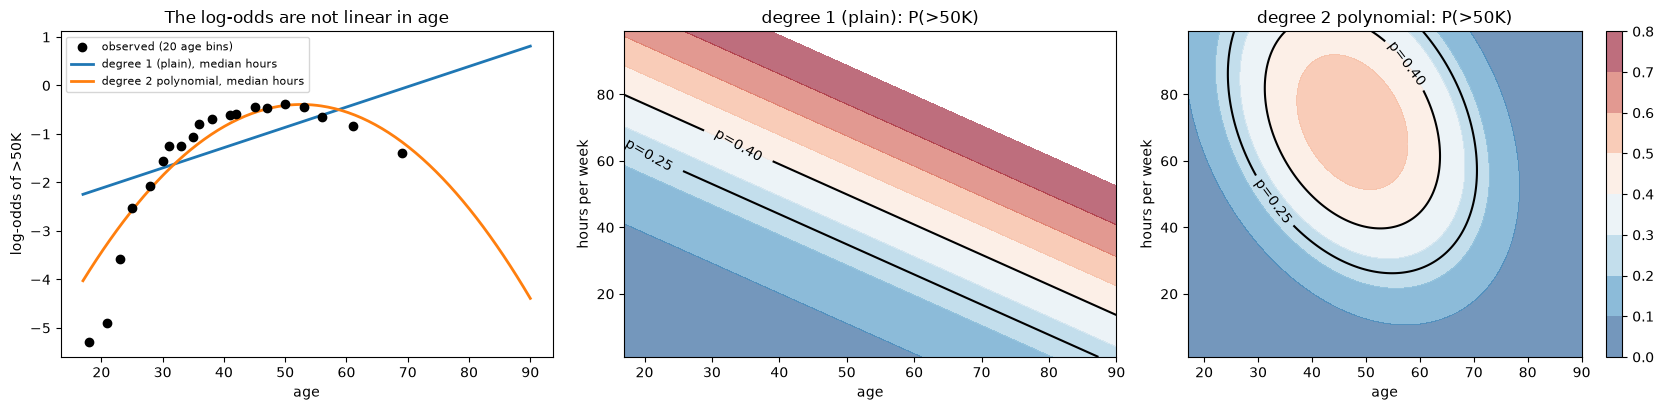

In [36]:
age_bins = pd.qcut(Xa_train["age"], 20, duplicates="drop")
empirical = ya_train.groupby(age_bins, observed=True).mean().clip(0.005, 0.995)
bin_centers = Xa_train["age"].groupby(age_bins, observed=True).median()
median_hours = Xa_train["hours-per-week"].median()
age_line = pd.DataFrame({"age": np.linspace(17, 90, 200), "hours-per-week": median_hours})

fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
axes[0].scatter(bin_centers, logit(empirical), color="black", zorder=3, label="observed (20 age bins)")
for name in ["degree 1 (plain)", "degree 2 polynomial"]:
    axes[0].plot(age_line["age"], logit(shape_models[name].predict_proba(age_line)[:, 1]), lw=2, label=f"{name}, median hours")
axes[0].set(xlabel="age", ylabel="log-odds of >50K", title="The log-odds are not linear in age")
axes[0].legend(fontsize=8)
a_grid, h_grid = np.meshgrid(np.linspace(17, 90, 200), np.linspace(1, 99, 200))
grid_adult = pd.DataFrame({"age": a_grid.ravel(), "hours-per-week": h_grid.ravel()})
for ax, name in zip(axes[1:], ["degree 1 (plain)", "degree 2 polynomial"]):
    grid_p = shape_models[name].predict_proba(grid_adult)[:, 1].reshape(a_grid.shape)
    filled = ax.contourf(a_grid, h_grid, grid_p, levels=np.linspace(0, 0.8, 9), cmap="RdBu_r", alpha=0.6)
    lines = ax.contour(a_grid, h_grid, grid_p, levels=[0.25, 0.4], colors="k", linewidths=1.5)
    ax.clabel(lines, fmt="p=%.2f")
    ax.set(xlabel="age", ylabel="hours per week", title=f"{name}: P(>50K)")
fig.colorbar(filled, ax=axes[2])
plt.tight_layout()
plt.show()

Left: the observed log-odds (black dots) rise and then fall with age, and the straight-line model can't follow. The degree-2 model bends. Middle vs right: the same contour levels are straight, parallel lines for the plain model but **curved** for the polynomial one. The boundary is linear in the *expanded* features (age, hours, age², age·hours, hours²), not in the original ones.

> 💡 **Interview angle:** "How can logistic regression learn a non-linear boundary?" — add non-linear basis functions (polynomials, splines, interactions, bins), which keeps the model linear in parameters and convex. Check the need with binned empirical log-odds plots, regularize the expanded features, and compare on validation log loss. For many complex interactions, switch to trees/boosting.

## 14. Hyperparameters and a Fair Head-to-Head 🟡

| Hyperparameter | What it controls | Sensible default / range |
|---|---|---|
| `C` | inverse regularization strength | 1.0; search `np.logspace(-3, 3)` with CV log loss |
| `l1_ratio` | L2 (0) ↔ elastic-net ↔ L1 (1) | 0; try {0, 0.5, 1} with `saga` when you want sparsity |
| `solver` | optimization algorithm (and allowed penalties) | `lbfgs`; `liblinear` (small, L1), `newton-cholesky` (n ≫ p), `saga` (elastic-net, big sparse) |
| `class_weight` | per-class loss weights | `None`; `"balanced"` + recalibration, or tune the threshold instead |
| `max_iter`, `tol` | when the solver stops | raise `max_iter` only after scaling |
| `fit_intercept` | include $\beta_0$ | `True` |
| decision threshold | converting probability to action | from costs; `TunedThresholdClassifierCV` |

The validation curve for `C` is in Section 5. Now a **fair comparison** against neighbouring classifiers on the breast-cancer data: same **5-fold × 3 repeats**, scaling inside pipelines, and ROC-AUC, log loss, accuracy and timings.

In [37]:
h2h_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)
contenders = {
    "LogisticRegression": make_pipeline(StandardScaler(), LogisticRegression()),
    "KNeighbors (k=15)": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15)),
    "GaussianNB": GaussianNB(),
    "SVC (RBF, calibrated)": make_pipeline(StandardScaler(), CalibratedClassifierCV(SVC(), ensemble=False)),
    "RandomForest (300 trees)": RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
}
h2h_rows = []
for name, model in contenders.items():
    res = cross_validate(model, X_bc, y_bc, cv=h2h_cv, scoring=["roc_auc", "neg_log_loss", "accuracy"])
    h2h_rows.append({"model": name, "ROC-AUC": res["test_roc_auc"].mean(), "log loss": -res["test_neg_log_loss"].mean(),
                     "± std (log loss)": res["test_neg_log_loss"].std(), "accuracy": res["test_accuracy"].mean(),
                     "fit (ms)": 1000 * res["fit_time"].mean(), "predict (ms)": 1000 * res["score_time"].mean()})
h2h = pd.DataFrame(h2h_rows).set_index("model").sort_values("log loss")
print(h2h.to_string(float_format=lambda v: f"{v:.4f}"))
best_ll, best_auc = h2h["log loss"].idxmin(), h2h["ROC-AUC"].idxmax()
print(f"\n→ Lowest log loss: {best_ll} | highest ROC-AUC: {best_auc}.")
print(f"→ Logistic regression: ROC-AUC {h2h.loc['LogisticRegression', 'ROC-AUC']:.4f}, log loss {h2h.loc['LogisticRegression', 'log loss']:.4f}, "
      f"fits in {h2h.loc['LogisticRegression', 'fit (ms)']:.1f} ms vs {h2h.loc['RandomForest (300 trees)', 'fit (ms)']:.0f} ms for the random forest.")

                          ROC-AUC  log loss  ± std (log loss)  accuracy  fit (ms)  predict (ms)
model                                                                                          
LogisticRegression         0.9946    0.0786            0.0284    0.9760    1.6430        2.5026
SVC (RBF, calibrated)      0.9953    0.0815            0.0277    0.9707    7.7170        3.0477
RandomForest (300 trees)   0.9898    0.1742            0.1312    0.9596  113.4822       32.9621
KNeighbors (k=15)          0.9906    0.2064            0.1464    0.9608    0.9756        4.7013
GaussianNB                 0.9877    0.6119            0.3004    0.9385    0.5616        1.8806

→ Lowest log loss: LogisticRegression | highest ROC-AUC: SVC (RBF, calibrated).
→ Logistic regression: ROC-AUC 0.9946, log loss 0.0786, fits in 1.6 ms vs 113 ms for the random forest.


On this small, nearly linearly separable dataset, regularized logistic regression is at or near the top on every metric, while being the fastest and most interpretable. On large tabular data with strong interactions, gradient boosting usually wins on accuracy, and logistic regression remains the baseline and the calibrated, explainable fallback.

> 💡 **Interview angle:** "When would you pick logistic regression over a random forest or boosting?" — when the signal is roughly additive in log-odds, data is small or very high-dimensional and sparse, you need calibrated probabilities, explanations (odds ratios, reason codes) or regulatory approval, or tight latency. Back it with a same-folds comparison like this one.

## 🔧 Build It From Scratch

We implement **binary L2-regularized logistic regression** with exactly scikit-learn's objective and an **unpenalized intercept**:

$$J(b, w) = \tfrac12\lVert w\rVert^2 + C\sum_{i=1}^{n}\Big[\log\big(1+e^{z_i}\big) - y_i z_i\Big], \qquad z_i = b + w^\top x_i$$

$$\nabla_b J = C\sum_i (p_i - y_i), \qquad \nabla_w J = w + C\,X^\top(p - y), \qquad \nabla^2 J = C\,A^\top S A + \text{diag}(0, 1, \dots, 1)$$

(with $A = [\mathbf{1}, X]$ and $S = \text{diag}(p_i(1-p_i))$). Two solvers:
1. **Gradient descent** with step $1/L$, where $L = 1 + \tfrac{C}{4}\lambda_{\max}(A^\top A)$ bounds the curvature (because $p(1-p) \le 1/4$).
2. **Newton's method** (a.k.a. IRLS): solve $\nabla^2 J \cdot \Delta = \nabla J$ each step, with a backtracking line search for safety.

Then we `assert` both match `LogisticRegression` (lbfgs) for several `C` values, and show that `liblinear` optimizes a slightly *different* objective because it also penalizes the intercept.

In [38]:
class LogisticRegressionScratch:
    """Binary logistic regression with scikit-learn's L2 objective: ½‖w‖² + C·Σ log loss (intercept unpenalized by default)."""

    def __init__(self, C=1.0, solver="gd", tol=1e-6, max_iter=500_000, penalize_intercept=False):
        self.C, self.solver, self.tol, self.max_iter, self.penalize_intercept = C, solver, tol, max_iter, penalize_intercept

    def _penalty_mask(self, d):
        mask = np.ones(d)
        mask[0] = 1.0 if self.penalize_intercept else 0.0
        return mask

    def _objective(self, A, y, theta, mask):
        z = A @ theta
        return self.C * np.sum(np.logaddexp(0, z) - y * z) + 0.5 * np.sum(mask * theta ** 2)

    def _gradient(self, A, y, theta, mask):
        p = expit(A @ theta)
        return self.C * A.T @ (p - y) + mask * theta, p

    def fit(self, X, y):
        X, y = np.asarray(X, dtype=float), np.asarray(y, dtype=float)
        A = np.column_stack([np.ones(len(X)), X])
        mask = self._penalty_mask(A.shape[1])
        theta = np.zeros(A.shape[1])
        self.history_ = []
        if self.solver == "gd":
            lipschitz = 1 + self.C * np.linalg.eigvalsh(A.T @ A).max() / 4
            for self.n_iter_ in range(1, self.max_iter + 1):
                grad, _ = self._gradient(A, y, theta, mask)
                self.history_.append(self._objective(A, y, theta, mask))
                if np.abs(grad).max() < self.tol:
                    break
                theta = theta - grad / lipschitz
        elif self.solver == "newton":
            for self.n_iter_ in range(1, 101):
                grad, p = self._gradient(A, y, theta, mask)
                current = self._objective(A, y, theta, mask)
                self.history_.append(current)
                hessian = self.C * (A.T * (p * (1 - p))) @ A + np.diag(mask)
                step = np.linalg.solve(hessian, grad)
                size = 1.0
                while self._objective(A, y, theta - size * step, mask) > current - 1e-4 * size * (grad @ step) and size > 1e-8:
                    size /= 2                                           # backtracking line search
                theta = theta - size * step
                if np.abs(size * step).max() < 1e-12:
                    break
        else:
            raise ValueError(f"unknown solver {self.solver!r}")
        self.intercept_, self.coef_ = theta[0], theta[1:]
        return self

    def predict_proba(self, X):
        p = expit(self.intercept_ + np.asarray(X, dtype=float) @ self.coef_)
        return np.column_stack([1 - p, p])

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X)[:, 1] >= threshold).astype(int)


scratch_rows = []
for c_value, solver in [(0.1, "gd"), (1.0, "gd"), (0.1, "newton"), (1.0, "newton"), (10.0, "newton")]:
    start = time.perf_counter()
    ours = LogisticRegressionScratch(C=c_value, solver=solver).fit(Z_train, y_train)
    seconds = time.perf_counter() - start
    reference = LogisticRegression(C=c_value, tol=1e-10, max_iter=100_000).fit(Z_train, y_train)
    assert np.allclose(ours.coef_, reference.coef_[0], atol=1e-4), (c_value, solver)
    assert np.isclose(ours.intercept_, reference.intercept_[0], atol=1e-4), (c_value, solver)
    assert np.allclose(ours.predict_proba(Z_val), reference.predict_proba(Z_val), atol=1e-5), (c_value, solver)
    assert np.array_equal(ours.predict(Z_val), reference.predict(Z_val))
    scratch_rows.append({"C": c_value, "solver": solver, "iterations": ours.n_iter_, "seconds": seconds,
                         "max |coef diff|": np.abs(ours.coef_ - reference.coef_[0]).max(),
                         "|intercept diff|": abs(ours.intercept_ - reference.intercept_[0])})
print(pd.DataFrame(scratch_rows).to_string(index=False, float_format=lambda v: f"{v:.2e}" if v < 0.01 else f"{v:.3f}"))
print("✅ gradient descent and Newton match scikit-learn's coefficients, probabilities and predictions (same C, unpenalized intercept)")

     C solver  iterations  seconds  max |coef diff|  |intercept diff|
 0.100     gd        1685    0.028         1.01e-06          1.19e-06
 1.000     gd       16225    0.276         1.21e-06          1.83e-07
 0.100 newton           9 5.49e-04         1.49e-07          1.17e-07
 1.000 newton          10 5.20e-04         1.43e-06          3.64e-08
10.000 newton          12 5.88e-04         3.39e-06          6.08e-07
✅ gradient descent and Newton match scikit-learn's coefficients, probabilities and predictions (same C, unpenalized intercept)


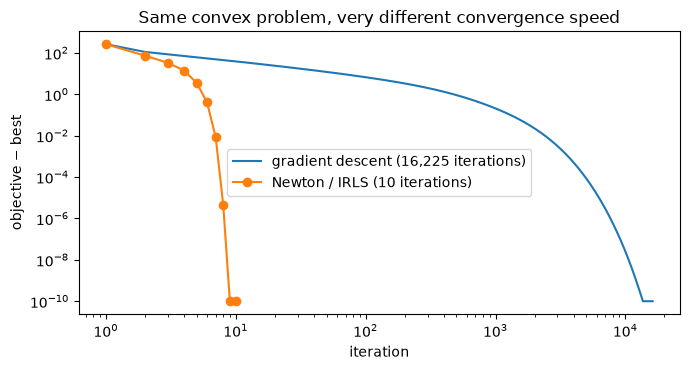

intercept: lbfgs / our default -0.2535 | liblinear -0.2047 = ours with a penalized intercept -0.2047 ✅


In [39]:
gd_run = LogisticRegressionScratch(C=1.0, solver="gd").fit(Z_train, y_train)
newton_run = LogisticRegressionScratch(C=1.0, solver="newton").fit(Z_train, y_train)
best_objective = min(min(gd_run.history_), min(newton_run.history_))
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(np.arange(1, len(gd_run.history_) + 1), np.maximum(np.array(gd_run.history_) - best_objective, 1e-10), label=f"gradient descent ({gd_run.n_iter_:,} iterations)")
ax.plot(np.arange(1, len(newton_run.history_) + 1), np.maximum(np.array(newton_run.history_) - best_objective, 1e-10), marker="o", label=f"Newton / IRLS ({newton_run.n_iter_} iterations)")
ax.set(xscale="log", yscale="log", xlabel="iteration", ylabel="objective − best", title="Same convex problem, very different convergence speed")
ax.legend()
plt.tight_layout()
plt.show()

# liblinear also penalizes the intercept (as a weight on a constant feature): match it by penalizing ours
liblinear_model = LogisticRegression(C=1.0, solver="liblinear", tol=1e-10, max_iter=100_000).fit(Z_train, y_train)
ours_penalized = LogisticRegressionScratch(C=1.0, solver="newton", penalize_intercept=True).fit(Z_train, y_train)
assert np.allclose(ours_penalized.coef_, liblinear_model.coef_[0], atol=1e-3) and np.isclose(ours_penalized.intercept_, liblinear_model.intercept_[0], atol=1e-3)
print(f"intercept: lbfgs / our default {newton_run.intercept_:.4f} | liblinear {liblinear_model.intercept_[0]:.4f} = ours with a penalized intercept "
      f"{ours_penalized.intercept_:.4f} ✅")

Takeaways: the gradient $C\,X^\top(p-y) + w$ is all you need to train the model, and Newton's method uses the curvature $X^\top S X$ to converge in about 10 steps instead of thousands. That is why second-order solvers (`newton-cholesky`, IRLS in statsmodels) shine when $p$ is moderate. "Same C" doesn't guarantee the same model across solvers: `liblinear` regularizes the intercept too.

## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — The wrong positive class (breast cancer's 0 = malignant)

In [40]:
raw_target_train = cancer.target.loc[X_train.index]           # scikit-learn's coding: 1 = benign
raw_target_val = cancer.target.loc[X_val.index]
raw_model = make_pipeline(StandardScaler(), LogisticRegression()).fit(X_train, raw_target_train)
right_model = make_pipeline(StandardScaler(), LogisticRegression()).fit(X_train, y_train)

print(f"❌ raw target: recall_score(...) = {recall_score(raw_target_val, raw_model.predict(X_val)):.3f}  ← that is BENIGN recall")
risk_wrong = raw_model.predict_proba(X_val)[:, 1]                # this is P(benign)!
top5 = np.argsort(-risk_wrong)[:5]
print(f"   'highest-risk' 5 patients by predict_proba[:, 1]: diagnoses {[str(cancer.target_names[t]) for t in raw_target_val.iloc[top5]]}")
right_pred = right_model.predict(X_val)
top5_right = np.argsort(-right_model.predict_proba(X_val)[:, 1])[:5]
print(f"✅ malignant = 1: malignant recall {recall_score(y_val, right_pred):.3f}, missed cancers {int(((right_pred == 0) & (y_val == 1)).sum())} of {int(y_val.sum())}")
print(f"   highest-risk 5 patients: diagnoses {[str(cancer.target_names[1 - t]) for t in y_val.iloc[top5_right]]}")

❌ raw target: recall_score(...) = 0.989  ← that is BENIGN recall
   'highest-risk' 5 patients by predict_proba[:, 1]: diagnoses ['benign', 'benign', 'benign', 'benign', 'benign']
✅ malignant = 1: malignant recall 0.925, missed cancers 4 of 53
   highest-risk 5 patients: diagnoses ['malignant', 'malignant', 'malignant', 'malignant', 'malignant']


### ❌ Pitfall 2 — Outdated or soon-to-break APIs

scikit-learn 1.8–1.9 changed several classification APIs. Deprecation warnings are future errors: fix them now.

In [41]:
Z_small_demo = StandardScaler().fit_transform(X_train)
for label, make_estimator in [
    ("SVC(probability=True)", lambda: SVC(probability=True).fit(Z_small_demo, y_train)),
    ("LogisticRegressionCV() with default arguments", lambda: LogisticRegressionCV().fit(Z_small_demo, y_train)),
]:
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        make_estimator()
    kinds = sorted({f"{w.category.__name__}: {str(w.message).splitlines()[0][:95]}" for w in caught if not issubclass(w.category, ConvergenceWarning)})
    print(f"❌ {label}:")
    for kind in kinds:
        print(f"     {kind}")

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    CalibratedClassifierCV(SVC(), ensemble=False).fit(Z_small_demo, y_train)
    LogisticRegressionCV(Cs=10, l1_ratios=(0.0,), scoring="neg_log_loss", use_legacy_attributes=False, cv=cv5).fit(Z_small_demo, y_train)
print(f"✅ CalibratedClassifierCV(SVC(), ensemble=False) and LogisticRegressionCV(..., l1_ratios=(0.0,), scoring='neg_log_loss', "
      f"use_legacy_attributes=False): {len(caught)} warnings")

❌ SVC(probability=True):
❌ LogisticRegressionCV() with default arguments:
✅ CalibratedClassifierCV(SVC(), ensemble=False) and LogisticRegressionCV(..., l1_ratios=(0.0,), scoring='neg_log_loss', use_legacy_attributes=False): 0 warnings


### ❌ Pitfall 3 — Reading an odds ratio as a risk ratio

In [42]:
rates = titanic.groupby("sex", observed=True)["survived"].mean()
raw_odds_ratio = (rates["male"] / (1 - rates["male"])) / (rates["female"] / (1 - rates["female"]))
raw_risk_ratio = rates["male"] / rates["female"]
print(f"❌ 'Men were {100 * (1 - raw_odds_ratio):.0f}% less likely to survive' (misreading the odds ratio {raw_odds_ratio:.3f})")
print(f"✅ Survival probability: women {rates['female']:.1%}, men {rates['male']:.1%} → risk ratio {raw_risk_ratio:.2f}, "
      f"i.e. men were {100 * (1 - raw_risk_ratio):.0f}% less likely to survive; the odds ratio exaggerates because survival is common")

❌ 'Men were 91% less likely to survive' (misreading the odds ratio 0.088)
✅ Survival probability: women 72.7%, men 19.1% → risk ratio 0.26, i.e. men were 74% less likely to survive; the odds ratio exaggerates because survival is common


Odds ratios approximate risk ratios only when the outcome is **rare** (say < 10%). For common outcomes, report probabilities, risk ratios or marginal effects.

### ❌ Pitfall 4 — A leaking feature that "knows" the answer

`boat` (lifeboat number) and `body` (body identification number) were recorded **after** the sinking. Including them gives a spectacular, useless model.

In [43]:
def titanic_leak_model():
    preprocess = make_column_transformer(
        (make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), make_column_selector(dtype_include="number")),
        (make_pipeline(SimpleImputer(strategy="constant", fill_value="missing"), OneHotEncoder(handle_unknown="ignore")),
         make_column_selector(dtype_exclude="number")))
    return make_pipeline(preprocess, LogisticRegression(max_iter=2000))


honest_cols = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
leak_results = {}
for label, cols in [("❌ with boat + body", honest_cols + ["boat", "body"]), ("✅ information available at boarding", honest_cols)]:
    frame = titanic[cols].copy()
    for col in frame.columns:
        if col == "pclass" or not pd.api.types.is_numeric_dtype(frame[col]):
            frame[col] = frame[col].astype(object)                      # treat as categorical text
    scores = cross_validate(titanic_leak_model(), frame, titanic["survived"], cv=cv5, scoring="roc_auc")
    leak_results[label] = scores["test_score"].mean()
    print(f"{label:38s} CV ROC-AUC {leak_results[label]:.4f}")
print("→ The near-perfect score comes from post-outcome information; in production, those columns don't exist yet.")

❌ with boat + body                     CV ROC-AUC 0.9937
✅ information available at boarding    CV ROC-AUC 0.8400
→ The near-perfect score comes from post-outcome information; in production, those columns don't exist yet.


### ❌ Pitfall 5 — Accuracy on imbalanced data

In [44]:
unweighted_val_pred = mammo_models["unweighted"].predict(Xm_val)
print(f"❌ accuracy: always 'no cancer' {accuracy_score(ym_val, np.zeros_like(ym_val)):.4f} | logistic regression {accuracy_score(ym_val, unweighted_val_pred):.4f} "
      f"→ looks like a tiny improvement over a useless model")
print(f"✅ the numbers that matter: recall@0.5 {recall_score(ym_val, unweighted_val_pred):.3f} (cancers caught), "
      f"PR-AUC {average_precision_score(ym_val, val_proba):.3f} vs {ym_val.mean():.3f} for random ranking, "
      f"cost-tuned threshold recall {threshold_table.loc['cost-optimal (OOF)', 'recall']:.3f}")

❌ accuracy: always 'no cancer' 0.9768 | logistic regression 0.9833 → looks like a tiny improvement over a useless model
✅ the numbers that matter: recall@0.5 0.385 (cancers caught), PR-AUC 0.650 vs 0.023 for random ranking, cost-tuned threshold recall 0.731


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — A vectorized logit
Write `log_odds(p)` for a NumPy array of probabilities.

In [45]:
def log_odds(p):
    return None  # TODO


check("log_odds", log_odds(np.array([0.1, 0.5, 0.75])), logit(np.array([0.1, 0.5, 0.75])), hint="np.log(p / (1 - p))")

⏳ log_odds: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def log_odds(p):
    p = np.asarray(p, dtype=float)
    return np.log(p) - np.log1p(-p)          # = log(p / (1 - p)), more accurate for p near 0 or 1


check("log_odds", log_odds(np.array([0.1, 0.5, 0.75])), logit(np.array([0.1, 0.5, 0.75])))
```
</details>

### 🟢 Exercise 2 — From an odds ratio to a probability
A customer's baseline default probability is **0.2**. A late payment has an odds ratio of **3**. What is the new default probability? Store it in `p_after`.

In [46]:
p_after = None  # TODO
check("p_after", p_after, 3 / 7, hint="odds = 0.2/0.8; new odds = 3 × odds; p = odds / (1 + odds)")

⏳ p_after: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
odds_before = 0.2 / (1 - 0.2)          # 0.25
odds_after = 3 * odds_before           # 0.75
p_after = odds_after / (1 + odds_after)
check("p_after", p_after, 3 / 7)
```

0.2 → 0.43, not 0.6: tripling the **odds** is not tripling the **probability**.
</details>

### 🟢 Exercise 3 — `class_weight` is just per-row weights
Fit `LogisticRegression()` on the standardized mammography training data `Zm_train` with a `sample_weight` vector that gives every row its "balanced" class weight. Store the fitted model's `coef_` in `weighted_coef`. It must equal the `class_weight="balanced"` model's coefficients.

In [47]:
Zm_train = StandardScaler().fit_transform(Xm_train)
weighted_coef = None  # TODO
check("weighted_coef", weighted_coef, LogisticRegression(class_weight="balanced").fit(Zm_train, ym_train).coef_,
      hint="w = len(y) / (2 * np.bincount(y)); sample_weight = w[ym_train]; LogisticRegression().fit(Zm_train, ym_train, sample_weight=...)")

⏳ weighted_coef: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
Zm_train = StandardScaler().fit_transform(Xm_train)
class_w = len(ym_train) / (2 * np.bincount(ym_train))
row_weights = class_w[ym_train.to_numpy()]
weighted_coef = LogisticRegression().fit(Zm_train, ym_train, sample_weight=row_weights).coef_
check("weighted_coef", weighted_coef, LogisticRegression(class_weight="balanced").fit(Zm_train, ym_train).coef_)
```

`class_weight` multiplies each row's loss term by its class weight. Nothing more mysterious is going on.
</details>

### 🟡 Exercise 4 — Expected calibration error (ECE)
Split `[0, 1]` into 10 equal-width bins. For each **non-empty** bin, take |mean predicted probability − observed positive rate| and weight it by the bin's share of rows. Compute the ECE of the unweighted mammography model's validation probabilities `val_proba`. Put a value exactly on an inner edge into the **lower** bin (`np.searchsorted(edges[1:-1], p)`), as scikit-learn does.

In [48]:
ece = None  # TODO

prob_true_ref, prob_pred_ref = calibration_curve(ym_val, val_proba, n_bins=10, strategy="uniform")
bin_counts_ref = np.bincount(np.searchsorted(np.linspace(0, 1, 11)[1:-1], val_proba), minlength=10)
ece_reference = np.sum(bin_counts_ref[bin_counts_ref > 0] / len(val_proba) * np.abs(prob_true_ref - prob_pred_ref))
check("ece", ece, ece_reference, hint="bins = np.searchsorted(np.linspace(0, 1, 11)[1:-1], p); loop over bins with rows.")

⏳ ece: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
edges = np.linspace(0, 1, 11)
bin_ids = np.searchsorted(edges[1:-1], val_proba)
y_np = ym_val.to_numpy()
ece = 0.0
for b in range(10):
    in_bin = bin_ids == b
    if in_bin.any():
        ece += in_bin.mean() * abs(val_proba[in_bin].mean() - y_np[in_bin].mean())

prob_true_ref, prob_pred_ref = calibration_curve(ym_val, val_proba, n_bins=10, strategy="uniform")
bin_counts_ref = np.bincount(np.searchsorted(np.linspace(0, 1, 11)[1:-1], val_proba), minlength=10)
ece_reference = np.sum(bin_counts_ref[bin_counts_ref > 0] / len(val_proba) * np.abs(prob_true_ref - prob_pred_ref))
check("ece", ece, ece_reference)
print(f"ECE = {ece:.4f}")
```

ECE is easy to explain but depends on the binning, and with 2% positives most rows sit in the first bin. Report it alongside the Brier score and a reliability diagram.
</details>

### 🟡 Exercise 5 — Reproduce multinomial `predict_proba` by hand
`wine_softmax` below is a standardized multinomial logistic regression. For the first 5 wines, compute the class probabilities yourself from the scaler, `coef_` (shape 3×13) and `intercept_`, using a softmax. Store the (5, 3) array in `manual_proba`.

In [49]:
wine_softmax = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(X_wine, y_wine)
manual_proba = None  # TODO
check("manual_proba", manual_proba, wine_softmax.predict_proba(X_wine.iloc[:5]),
      hint="Z = wine_softmax[0].transform(X_wine.iloc[:5]); logits = Z @ coef_.T + intercept_; softmax(logits, axis=1)")

⏳ manual_proba: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
wine_softmax = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(X_wine, y_wine)
Z_first5 = wine_softmax[0].transform(X_wine.iloc[:5])
lr_wine = wine_softmax[-1]
logits = Z_first5 @ lr_wine.coef_.T + lr_wine.intercept_          # shape (5, 3)
logits = logits - logits.max(axis=1, keepdims=True)               # stability
manual_proba = np.exp(logits) / np.exp(logits).sum(axis=1, keepdims=True)
check("manual_proba", manual_proba, wine_softmax.predict_proba(X_wine.iloc[:5]))
```
</details>

### 🔴 Exercise 6 — Newton's method (IRLS) with standard errors, matching statsmodels

Implement **unpenalized** logistic regression with Newton's method on the Titanic design matrix `X_titanic_design` (add a leading column of ones) and labels `y_titanic`. Iterate $\beta \leftarrow \beta + (A^\top S A)^{-1} A^\top (y - p)$ until the step is tiny. The **standard errors** are $\sqrt{\text{diag}\big((A^\top S A)^{-1}\big)}$ at the solution. Return `np.concatenate([beta, se])`. It must match `titanic_fit` (statsmodels).

In [50]:
sm_order = ["Intercept"] + [name_map[c] for c in X_titanic_design.columns]


def irls_logistic(X, y, max_iter=50):
    # TODO: Newton/IRLS; return np.concatenate([beta, standard_errors])
    return None


check("irls_logistic", irls_logistic(X_titanic_design, y_titanic),
      np.concatenate([titanic_fit.params[sm_order].to_numpy(), titanic_fit.bse[sm_order].to_numpy()]), rtol=1e-4, atol=1e-6,
      hint="A = [1, X]; p = expit(A @ beta); H = A.T @ (A * (p*(1-p))[:, None]); beta += solve(H, A.T @ (y - p)); se = sqrt(diag(inv(H)))")

⏳ irls_logistic: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
sm_order = ["Intercept"] + [name_map[c] for c in X_titanic_design.columns]


def irls_logistic(X, y, max_iter=50):
    A = np.column_stack([np.ones(len(X)), np.asarray(X, dtype=float)])
    y = np.asarray(y, dtype=float)
    beta = np.zeros(A.shape[1])
    for _ in range(max_iter):
        p = expit(A @ beta)
        hessian = A.T @ (A * (p * (1 - p))[:, None])       # AᵀSA (Fisher information)
        step = np.linalg.solve(hessian, A.T @ (y - p))
        beta = beta + step
        if np.abs(step).max() < 1e-10:
            break
    p = expit(A @ beta)
    hessian = A.T @ (A * (p * (1 - p))[:, None])
    standard_errors = np.sqrt(np.diag(np.linalg.inv(hessian)))
    return np.concatenate([beta, standard_errors])


check("irls_logistic", irls_logistic(X_titanic_design, y_titanic),
      np.concatenate([titanic_fit.params[sm_order].to_numpy(), titanic_fit.bse[sm_order].to_numpy()]), rtol=1e-4, atol=1e-6)
```

The inverse Fisher information gives the standard errors behind every p-value and odds-ratio CI in Section 8. On separable data $A^\top S A$ becomes nearly singular as $p \to 0/1$, which is exactly why those SEs explode (Section 9).
</details>

## 🚀 Mini Project: Credit-Risk Scoring With a Cost-Based Threshold

**Goal:** decide which loan applicants to reject, using the German credit data (1,000 applicants, 20 features, 30% "bad" credit risks). The dataset documentation gives the **cost matrix**: approving an applicant who turns out bad costs **5**, rejecting a good applicant costs **1**.

**Plan:** hold out a **test set of 200 applicants** (touched once, at the end). With only 800 development rows, a single validation split would be too noisy, so every choice (C, `l1_ratio`, the threshold, the calibration check) uses **5-fold cross-validation / out-of-fold predictions** on the development set.

**Steps:** load & baselines → tune C and `l1_ratio` → out-of-fold calibration and cost-based threshold → odds-ratio interpretation → single test evaluation → conclusions.

### Step 1 — Load, split, and cost baselines

In [51]:
credit = fetch_openml("credit-g", version=1, as_frame=True, data_home=DATA_DIR)
X_credit = credit.data
y_credit = (credit.target == "bad").astype(int).rename("bad")           # positive class = bad credit risk
COST_APPROVE_BAD, COST_REJECT_GOOD = 5.0, 1.0
X_dev, X_test_credit, y_dev, y_test_credit = train_test_split(X_credit, y_credit, test_size=0.2, stratify=y_credit, random_state=SEED)
print(f"credit-g: {X_credit.shape[0]} applicants, {X_credit.shape[1]} features "
      f"({X_credit.select_dtypes('number').shape[1]} numeric, {X_credit.select_dtypes(exclude='number').shape[1]} categorical)")
print(f"development {len(X_dev)} · test {len(X_test_credit)} | bad rate: dev {y_dev.mean():.1%}, test {y_test_credit.mean():.1%}")


def credit_cost(y_true, y_pred):
    """Average cost per applicant. y_pred = 1 means 'reject' (predicted bad)."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    approved_bad = np.sum((y_pred == 0) & (y_true == 1))
    rejected_good = np.sum((y_pred == 1) & (y_true == 0))
    return (COST_APPROVE_BAD * approved_bad + COST_REJECT_GOOD * rejected_good) / len(y_true)


print(f"baseline cost per applicant (dev): approve everyone {credit_cost(y_dev, np.zeros(len(y_dev))):.3f} | "
      f"reject everyone {credit_cost(y_dev, np.ones(len(y_dev))):.3f}")

credit-g: 1000 applicants, 20 features (7 numeric, 13 categorical)
development 800 · test 200 | bad rate: dev 30.0%, test 30.0%
baseline cost per applicant (dev): approve everyone 1.500 | reject everyone 0.700


### Step 2 — Tune C and l1_ratio with cross-validated log loss

Numeric columns are standardized, categoricals one-hot encoded, all inside the pipeline so every CV fold is leakage-free. `saga` is the solver that supports L2, elastic-net and L1 with an unpenalized intercept.

In [52]:
def credit_preprocessor():
    return make_column_transformer((StandardScaler(), make_column_selector(dtype_include="number")),
                                   (OneHotEncoder(handle_unknown="ignore"), make_column_selector(dtype_exclude="number")),
                                   verbose_feature_names_out=False)


start = time.perf_counter()
credit_search = GridSearchCV(make_pipeline(credit_preprocessor(), LogisticRegression(solver="saga", max_iter=10_000)),
                             {"logisticregression__C": np.logspace(-3, 2, 11), "logisticregression__l1_ratio": [0.0, 0.5, 1.0]},
                             cv=cv5, scoring="neg_log_loss").fit(X_dev, y_dev)
cv_grid = pd.DataFrame(credit_search.cv_results_)
cv_grid["C"] = cv_grid["param_logisticregression__C"].astype(float)
cv_grid["l1_ratio"] = cv_grid["param_logisticregression__l1_ratio"].astype(float)
print(f"grid search: {len(cv_grid)} settings × 5 folds in {time.perf_counter() - start:.1f}s")
print((-cv_grid.pivot(index="C", columns="l1_ratio", values="mean_test_score")).round(4).to_string())
best_params = credit_search.best_params_
print(f"\n🏆 best: C = {best_params['logisticregression__C']:.3g}, l1_ratio = {best_params['logisticregression__l1_ratio']} | "
      f"CV log loss {-credit_search.best_score_:.4f} (constant 30% prediction: {log_loss(y_dev, np.full(len(y_dev), y_dev.mean())):.4f})")

grid search: 33 settings × 5 folds in 8.9s
l1_ratio     0.0     0.5     1.0
C                               
0.0010    0.5942  0.6117  0.6129
0.0032    0.5713  0.6111  0.6117
0.0100    0.5380  0.6067  0.6109
0.0316    0.5095  0.5546  0.5744
0.1000    0.4999  0.5111  0.5276
0.3162    0.5068  0.5030  0.5059
1.0000    0.5208  0.5174  0.5180
3.1623    0.5343  0.5335  0.5359
10.0000   0.5434  0.5437  0.5458
31.6228   0.5484  0.5489  0.5503
100.0000  0.5509  0.5513  0.5521

🏆 best: C = 0.1, l1_ratio = 0.0 | CV log loss 0.4999 (constant 30% prediction: 0.6109)


### Step 3 — Out-of-fold probabilities: calibration check and the cost-optimal threshold

Out-of-fold (OOF) predictions: each development applicant is scored by a model that didn't train on them. For calibrated probabilities the theory says reject when $p > \frac{c_{\text{reject good}}}{c_{\text{reject good}} + c_{\text{approve bad}}} = \frac{1}{6}$.

OOF ROC-AUC 0.7813 | OOF Brier 0.1663 (constant 30%: 0.2100)
cost-optimal OOF threshold 0.18 (cost 0.512) | theory 1/6 = 0.167 (cost 0.536) | 0.5 (cost 0.978)


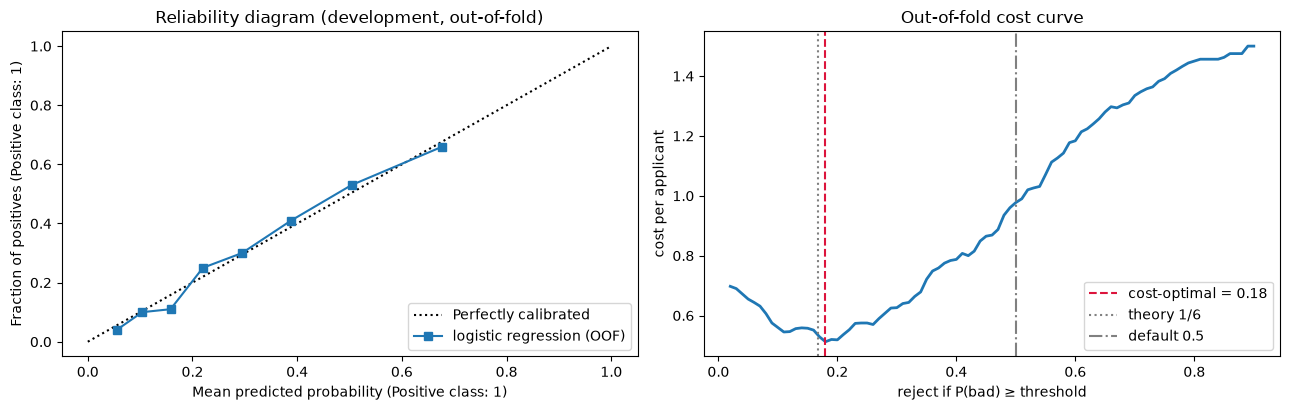

In [53]:
best_credit = credit_search.best_estimator_
oof_credit = cross_val_predict(best_credit, X_dev, y_dev, cv=cv5, method="predict_proba")[:, 1]
print(f"OOF ROC-AUC {roc_auc_score(y_dev, oof_credit):.4f} | OOF Brier {brier_score_loss(y_dev, oof_credit):.4f} "
      f"(constant 30%: {brier_score_loss(y_dev, np.full(len(y_dev), y_dev.mean())):.4f})")

credit_thresholds = np.linspace(0.02, 0.90, 89)
credit_costs = np.array([credit_cost(y_dev, (oof_credit >= t).astype(int)) for t in credit_thresholds])
chosen_threshold = float(credit_thresholds[credit_costs.argmin()])
theory_threshold = COST_REJECT_GOOD / (COST_REJECT_GOOD + COST_APPROVE_BAD)
print(f"cost-optimal OOF threshold {chosen_threshold:.2f} (cost {credit_costs.min():.3f}) | theory 1/6 = {theory_threshold:.3f} "
      f"(cost {credit_cost(y_dev, (oof_credit >= theory_threshold).astype(int)):.3f}) | 0.5 (cost {credit_cost(y_dev, (oof_credit >= 0.5).astype(int)):.3f})")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
CalibrationDisplay.from_predictions(y_dev, oof_credit, n_bins=8, strategy="quantile", name="logistic regression (OOF)", ax=axes[0])
axes[0].set(title="Reliability diagram (development, out-of-fold)")
axes[1].plot(credit_thresholds, credit_costs, lw=2)
axes[1].axvline(chosen_threshold, ls="--", color="crimson", label=f"cost-optimal = {chosen_threshold:.2f}")
axes[1].axvline(theory_threshold, ls=":", color="gray", label="theory 1/6")
axes[1].axvline(0.5, ls="-.", color="gray", label="default 0.5")
axes[1].set(xlabel="reject if P(bad) ≥ threshold", ylabel="cost per applicant", title="Out-of-fold cost curve")
axes[1].legend()
plt.tight_layout()
plt.show()

### Step 4 — Interpretation: odds ratios with confidence intervals

For explanation we fit a compact **unpenalized** model with `statsmodels` on the development rows: checking-account status, duration, credit amount (log), credit history, savings, installment rate and age. Category coefficients are relative to the **first category** of each column (the reference), printed below.

In [54]:
credit_dev = X_dev.assign(bad=y_dev.to_numpy())
credit_formula = ("bad ~ C(checking_status) + duration + np.log(credit_amount) + C(credit_history)"
                  " + C(savings_status) + installment_commitment + age")
credit_logit = smf.logit(credit_formula, data=credit_dev).fit(disp=0)
for col in ["checking_status", "credit_history", "savings_status"]:
    print(f"reference level for {col}: '{X_dev[col].cat.categories[0]}'")
credit_ci = credit_logit.conf_int()
credit_or = pd.DataFrame({"odds ratio": np.exp(credit_logit.params), "OR 2.5%": np.exp(credit_ci[0]), "OR 97.5%": np.exp(credit_ci[1]),
                          "p-value": credit_logit.pvalues}).drop(index="Intercept")
print(credit_or.to_string(float_format=lambda v: f"{v:.3g}"))

no_checking = "C(checking_status)[T.no checking]"
duration_or_12 = np.exp(12 * credit_logit.params["duration"])
duration_ci_12 = np.exp(12 * credit_ci.loc["duration"])
print(f"\n→ Applicants with no checking account had {credit_or.loc[no_checking, 'odds ratio']:.2f}× the odds of being a bad risk "
      f"compared with '0<=X<200' (95% CI {credit_or.loc[no_checking, 'OR 2.5%']:.2f}–{credit_or.loc[no_checking, 'OR 97.5%']:.2f}).")
print(f"→ Every extra 12 months of loan duration multiplied the odds of bad credit by {duration_or_12:.2f} "
      f"(95% CI {duration_ci_12[0]:.2f}–{duration_ci_12[1]:.2f}).")
significant = credit_or.index[credit_or["p-value"] < 0.05].tolist()
print(f"→ Terms significant at 5%: {significant}")

reference level for checking_status: '0<=X<200'
reference level for credit_history: 'all paid'
reference level for savings_status: '100<=X<500'
                                                     odds ratio  OR 2.5%  OR 97.5%  p-value
C(checking_status)[T.<0]                                   1.42    0.929      2.16    0.106
C(checking_status)[T.>=200]                               0.652    0.311      1.37    0.259
C(checking_status)[T.no checking]                         0.279    0.176     0.444 6.78e-08
C(credit_history)[T.critical/other existing credit]       0.242    0.112     0.526 0.000336
C(credit_history)[T.delayed previously]                   0.474    0.197      1.14   0.0956
C(credit_history)[T.existing paid]                        0.498    0.243      1.02   0.0572
C(credit_history)[T.no credits/all paid]                   1.24    0.435      3.52     0.69
C(savings_status)[T.500<=X<1000]                           0.58    0.219      1.54    0.273
C(savings_status)[T.<100]   

### Step 5 — The one and only test evaluation

`GridSearchCV` already refit the best pipeline on all 800 development rows. We apply the threshold chosen in Step 3 to the untouched test set.

In [55]:
test_proba_credit = best_credit.predict_proba(X_test_credit)[:, 1]
decision_rows = []
for label, pred in [(f"logistic, cost-tuned threshold {chosen_threshold:.2f}", (test_proba_credit >= chosen_threshold).astype(int)),
                    ("logistic, default threshold 0.5", (test_proba_credit >= 0.5).astype(int)),
                    ("approve everyone", np.zeros(len(y_test_credit), dtype=int)),
                    ("reject everyone", np.ones(len(y_test_credit), dtype=int))]:
    decision_rows.append({"policy": label, "cost per applicant": credit_cost(y_test_credit, pred),
                          "bad risks caught (recall)": recall_score(y_test_credit, pred, zero_division=0),
                          "rejections that were bad (precision)": precision_score(y_test_credit, pred, zero_division=0),
                          "approval rate": 1 - pred.mean()})
decision_table = pd.DataFrame(decision_rows).set_index("policy")
print(decision_table.round(3).to_string())
print(f"\ntest ROC-AUC {roc_auc_score(y_test_credit, test_proba_credit):.4f} | log loss {log_loss(y_test_credit, test_proba_credit):.4f} | "
      f"Brier {brier_score_loss(y_test_credit, test_proba_credit):.4f}")
tuned_pred_test = (test_proba_credit >= chosen_threshold).astype(int)
print("confusion matrix at the tuned threshold [rows: actual good/bad, columns: approve/reject]:")
print(confusion_matrix(y_test_credit, tuned_pred_test, labels=[0, 1]))

                                     cost per applicant  bad risks caught (recall)  rejections that were bad (precision)  approval rate
policy                                                                                                                                 
logistic, cost-tuned threshold 0.18               0.535                      0.883                                 0.424          0.375
logistic, default threshold 0.5                   0.810                      0.500                                 0.714          0.790
approve everyone                                  1.500                      0.000                                 0.000          1.000
reject everyone                                   0.700                      1.000                                 0.300          0.000

test ROC-AUC 0.8096 | log loss 0.4800 | Brier 0.1547
confusion matrix at the tuned threshold [rows: actual good/bad, columns: approve/reject]:
[[68 72]
 [ 7 53]]


### Step 6 — Conclusions (computed)

In [56]:
tuned_cost = decision_table.iloc[0]["cost per applicant"]
default_cost = decision_table.iloc[1]["cost per applicant"]
best_baseline = decision_table.iloc[2:]["cost per applicant"].min()
print(f"1. Regularization: CV picked C = {best_params['logisticregression__C']:.3g} with l1_ratio = {best_params['logisticregression__l1_ratio']} "
      f"(CV log loss {-credit_search.best_score_:.4f}).")
print(f"2. Threshold: the out-of-fold cost-optimal threshold {chosen_threshold:.2f} is close to the theoretical 1/6 = {theory_threshold:.3f}, "
      f"consistent with reasonably calibrated probabilities (OOF Brier {brier_score_loss(y_dev, oof_credit):.3f}).")
print(f"3. On the test set the tuned policy costs {tuned_cost:.3f} per applicant vs {default_cost:.3f} at 0.5 and {best_baseline:.3f} for the best "
      f"trivial policy → {100 * (1 - tuned_cost / best_baseline):.0f}% cheaper than the best trivial policy.")
print(f"4. It rejects {1 - decision_table.iloc[0]['approval rate']:.0%} of applicants and catches "
      f"{decision_table.iloc[0]['bad risks caught (recall)']:.0%} of bad risks: with a 5:1 cost ratio, rejecting some good customers is the price.")
print(f"5. Strongest explainable signals (compact model): no checking account OR {credit_or.loc[no_checking, 'odds ratio']:.2f}; "
      f"12 more months of duration OR {duration_or_12:.2f}.")

1. Regularization: CV picked C = 0.1 with l1_ratio = 0.0 (CV log loss 0.4999).
2. Threshold: the out-of-fold cost-optimal threshold 0.18 is close to the theoretical 1/6 = 0.167, consistent with reasonably calibrated probabilities (OOF Brier 0.166).
3. On the test set the tuned policy costs 0.535 per applicant vs 0.810 at 0.5 and 0.700 for the best trivial policy → 24% cheaper than the best trivial policy.
4. It rejects 62% of applicants and catches 88% of bad risks: with a 5:1 cost ratio, rejecting some good customers is the price.
5. Strongest explainable signals (compact model): no checking account OR 0.28; 12 more months of duration OR 1.47.


**Stretch goals**
1. Replace the fixed 5:1 costs with a profit model (interest earned on good loans vs loss given default) and re-tune the threshold.
2. Use `TunedThresholdClassifierCV(best_credit, scoring=make_scorer(credit_cost, greater_is_better=False))` and compare its threshold with Step 3.
3. Bootstrap the development set to get a confidence interval for the chosen threshold and the expected cost.
4. Compare with `HistGradientBoostingClassifier` on the same folds: does it lower the cost enough to justify losing odds-ratio explanations?
5. Check fairness: compare approval rates and error rates across the `personal_status` groups (which mixes sex and marital status), and discuss whether that feature should be used at all.

### 🗣️ How to talk about this in an interview
- "I defined the positive class as 'bad credit' and optimized the stated **5:1 cost matrix**, not accuracy. Approving a bad loan costs five times as much as rejecting a good one."
- "With only 800 development rows I used **5-fold CV** for C and `l1_ratio` and **out-of-fold predictions** to pick the threshold and check calibration, then scored the 200-row test set exactly once."
- "The cost-optimal threshold landed near the theoretical $c_{FP}/(c_{FP}+c_{FN}) = 1/6$, a useful sanity check that the probabilities are calibrated."
- "For explanations I fitted a compact `statsmodels` logit and reported **odds ratios with 95% CIs**, e.g. loan duration and checking-account status, while making clear these are associations, not causal effects."
- "Next steps would be a profit-based objective, confidence intervals via bootstrapping, a fairness review of sensitive features, and monitoring calibration drift after deployment."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. Why is logistic regression called a linear classifier if the sigmoid is non-linear?**

<details><summary>Show answer</summary>

- **30-second answer:** It models the **log-odds** as a linear function, $\log\frac{p}{1-p} = \beta_0 + \beta^\top x$. Because the sigmoid is monotonic, $p \ge t \iff \beta_0 + \beta^\top x \ge \text{logit}(t)$, so the decision boundary is a hyperplane in feature space. The non-linearity only maps scores to probabilities.
- **Go deeper:** Different thresholds give parallel hyperplanes. Non-linear boundaries need non-linear features (polynomials, splines, interactions), which keep the model linear in parameters and convex. It's a generalized linear model (GLM) with a Bernoulli distribution and logit link.
- **❌ Common wrong answer:** "It's non-linear because of the sigmoid," or "it's linear regression with a threshold."

</details>

**Q2. Why do we train logistic regression with log loss instead of mean squared error?**

<details><summary>Show answer</summary>

- **30-second answer:** Log loss is the negative log-likelihood of a Bernoulli model, so minimizing it is maximum likelihood estimation. It's **convex** in β (Hessian $X^\top S X \succeq 0$), and its gradient $X^\top(p-y)$ stays large when the model is confidently wrong. MSE on sigmoid outputs is non-convex, and its gradient carries a factor $p(1-p)$ that vanishes exactly for confident mistakes.
- **Go deeper:** Log loss is a strictly proper scoring rule: it's minimized by the true probabilities, which is one reason logistic regression tends to be calibrated. We showed MSE's plateau on real data and a gradient about 200× smaller for a confidently wrong example.
- **❌ Common wrong answer:** "MSE would work the same, log loss is just a convention."

</details>

**Q3. How do you interpret a coefficient of 0.7? And an odds ratio of 0.08 for "male" in a survival model?**

<details><summary>Show answer</summary>

- **30-second answer:** 0.7 means +1 unit adds 0.7 to the log-odds, i.e. multiplies the **odds** by $e^{0.7} \approx 2.01$, holding the other features fixed. An odds ratio of 0.08 means men's odds of survival were 8% of women's odds with the same class, age and family size, not "92% less likely" in probability terms.
- **Go deeper:** The probability effect depends on the baseline (at most β/4 near p = 0.5). For stakeholders, report average marginal effects (we found about −38 percentage points) or risk ratios. For continuous features choose a meaningful unit ($e^{10\beta}$ per decade). With a CI: exponentiate the CI endpoints.
- **❌ Common wrong answer:** "A coefficient of 0.7 increases the probability by 0.7 (or by 70%)."

</details>

**Q4. Derive the gradient of the logistic regression loss.**

<details><summary>Show answer</summary>

- **30-second answer:** Per example, $\ell = -y\log p - (1-y)\log(1-p)$ with $p = \sigma(z)$, $z = w^\top x + b$. Using $\sigma'(z) = p(1-p)$: $\frac{\partial\ell}{\partial p} = \frac{p-y}{p(1-p)}$, so $\frac{\partial\ell}{\partial z} = p - y$ and $\nabla_w \ell = (p - y)\,x$. Over the dataset: $\nabla_w = X^\top(p - y)$ (divide by n for the mean loss), plus $\lambda w$ for L2.
- **Go deeper:** The Hessian is $X^\top S X$ with $S = \text{diag}(p(1-p))$, giving Newton's method / IRLS: $\beta \leftarrow \beta + (X^\top S X)^{-1}X^\top(y-p)$. It converges in about 10 iterations versus thousands for gradient descent (see 🔧). The inverse Hessian at the optimum gives the standard errors.
- **❌ Common wrong answer:** Forgetting the $p(1-p)$ cancellation and writing $X^\top(p-y)\,p(1-p)$, which is the MSE gradient.

</details>

**Q5. What happens when the training data is perfectly separable?**

<details><summary>Show answer</summary>

- **30-second answer:** The maximum-likelihood estimate doesn't exist. Scaling up the coefficients always lowers the log loss, so the unpenalized solution runs off to infinity: huge coefficients and standard errors, solver warnings, and 0/1 probabilities that are wildly overconfident on new data.
- **Go deeper:** We saw training accuracy hit 100% and validation log loss get many times worse as C grew. Fixes: L2 regularization (scikit-learn's default C = 1), Firth's penalized likelihood for inference, removing leaking or ultra-rare features, or merging sparse categories. Quasi-separation (almost perfect, e.g. a leaking `boat` feature) causes the same symptoms.
- **❌ Common wrong answer:** "Perfect separation is great, the model is perfect."

</details>

**Q6. What does C control, and how do L1 and L2 differ in logistic regression?**

<details><summary>Show answer</summary>

- **30-second answer:** scikit-learn minimizes $C\sum\text{logloss} + \text{penalty}(w)$, so C is the **inverse** regularization strength: small C = strong shrinkage. L2 (`l1_ratio=0`) shrinks all coefficients smoothly and is stable with correlated features. L1 (`l1_ratio=1`) sets some exactly to zero (feature selection). Elastic-net mixes both.
- **Go deeper:** In scikit-learn ≥ 1.8 `penalty=` is deprecated; use `l1_ratio` and `C` (and `C=np.inf` for no penalty). Solvers: lbfgs/newton-cg/newton-cholesky/sag support L2 only, liblinear supports L1/L2 (binary, penalizes the intercept), and saga supports everything. Scale features first, tune C on a log grid with CV log loss, and remember C multiplies a *sum*, so the effective strength changes with n.
- **❌ Common wrong answer:** "Larger C means more regularization" (it's the opposite of Ridge's alpha).

</details>

**Q7. One-vs-rest vs multinomial (softmax) logistic regression?**

<details><summary>Show answer</summary>

- **30-second answer:** OvR trains K independent binary classifiers and renormalizes their probabilities. Multinomial trains one model with a softmax over K scores and one cross-entropy loss. For mutually exclusive classes, multinomial is the proper likelihood and usually gives better probabilities (lower log loss). OvR is useful for multi-label problems or to parallelize any binary learner.
- **Go deeper:** Softmax with K = 2 reduces to the sigmoid on the score difference. Softmax coefficients are identified only up to a common shift (the penalty fixes it). In scikit-learn 1.9 `LogisticRegression` is multinomial for every solver except liblinear. `multi_class=` was removed, so use `OneVsRestClassifier` explicitly.
- **❌ Common wrong answer:** "They're the same; OvR is just faster."

</details>

**Q8. How do you handle heavy class imbalance with logistic regression?**

<details><summary>Show answer</summary>

- **30-second answer:** Keep stratified splits and evaluate with PR-AUC, recall at a required precision, or expected cost, not accuracy. Then either **tune the decision threshold** on validation/out-of-fold predictions, or use `class_weight="balanced"` (or resampling) and **recalibrate** if you need probabilities.
- **Go deeper:** Weighting mostly shifts the intercept by about $\log(n_0/n_1)$, so ROC-AUC barely moves while predicted probabilities inflate (on mammography, Brier went from 0.013 to 0.085). King & Zeng's prior correction adjusts the intercept analytically. Resample only inside training folds. More data from the rare class usually beats any trick.
- **❌ Common wrong answer:** "Always oversample to 50/50 and use accuracy."

</details>

**Q9. How do you choose the decision threshold?**

<details><summary>Show answer</summary>

- **30-second answer:** From the costs of errors. For calibrated probabilities, predict positive when $p > c_{FP}/(c_{FP}+c_{FN})$. In practice, minimize expected cost (or meet a recall/precision constraint) on validation or out-of-fold predictions, e.g. with `TunedThresholdClassifierCV`, then report the chosen policy once on the test set.
- **Go deeper:** F1-optimal thresholds ignore business costs. Threshold choice depends on the base rate, so re-tune after prevalence shifts. Consider capacity constraints ("we can review 200 cases a day" → top-k), and show a cost curve with uncertainty (bootstrap) to stakeholders.
- **❌ Common wrong answer:** "Always use 0.5," or "pick the threshold that maximizes accuracy on the test set."

</details>

**Q10. Is logistic regression calibrated? When does it stop being calibrated?**

<details><summary>Show answer</summary>

- **30-second answer:** Often yes: maximum likelihood with an intercept makes the average predicted probability equal the observed rate on the training data, and log loss rewards calibrated probabilities. It becomes miscalibrated with class weights or resampling, strong regularization, missing non-linearities, separation, or distribution shift.
- **Go deeper:** Check with a reliability diagram, the Brier score, log loss, or ECE on held-out data. Fix with Platt (sigmoid) or isotonic calibration via `CalibratedClassifierCV` on data the model didn't train on (`FrozenEstimator` for a prefit model). Calibration doesn't change the ranking much (ROC-AUC stays similar).
- **❌ Common wrong answer:** "Any model that outputs numbers between 0 and 1 gives probabilities."

</details>

**Q11. What are the assumptions of logistic regression?**

<details><summary>Show answer</summary>

- **30-second answer:** A binary (or categorical) outcome, **linearity of the log-odds** in the features, independent observations, no perfect separation, not-too-strong multicollinearity, and enough events per parameter. It does **not** assume normal errors, constant variance, or normally distributed features.
- **Go deeper:** Check linearity with binned empirical log-odds plots (age vs income was an inverted U), and fix with splines/polynomials. For dependence (repeated customers) use cluster-robust SEs or mixed models. A rule of thumb is ≥ 10–20 events of the rarer class per estimated parameter for stable unpenalized inference.
- **❌ Common wrong answer:** Listing the linear-regression assumptions (normal, homoscedastic residuals).

</details>

### 💻 Coding

**Q12. Implement binary logistic regression with gradient descent in NumPy, numerically stably.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  from scipy.special import expit

  def fit_logreg(X, y, lr=0.1, epochs=5000, lam=0.0):
      X = np.c_[np.ones(len(X)), X]                     # intercept column
      w = np.zeros(X.shape[1])
      for _ in range(epochs):
          p = expit(X @ w)                              # stable sigmoid
          grad = X.T @ (p - y) / len(y)
          grad[1:] += lam * w[1:]                       # L2, intercept unpenalized
          w -= lr * grad
      return w

  def log_loss_from_z(z, y):                            # never log(sigmoid(z)) directly
      return np.mean(np.logaddexp(0, z) - y * z)
  ```
- **Go deeper:** Standardize features, verify the gradient with finite differences, stop on the gradient norm, and compare with `LogisticRegression(C=1/(lam*n))`. Mention Newton/IRLS for fast convergence and mini-batch SGD for huge data. The 🔧 section asserts equality with scikit-learn.
- **❌ Common wrong answer:** `np.log(1/(1+np.exp(-z)))`, which overflows and gives `-inf`, or penalizing the intercept.

</details>

### 🐛 Debugging Scenarios

**Q13. Your logistic regression reaches 0.99 ROC-AUC in cross-validation but performs poorly after launch. What do you investigate?**

<details><summary>Show answer</summary>

- **30-second answer:** **Leakage** first: features recorded after the outcome (like Titanic's `boat` and `body`, which pushed CV AUC from 0.84 to 0.99), target-derived encodings, or preprocessing fit on all data. Then train/serve skew and distribution shift: time-based splits, different category vocabularies, missing-value handling.
- **Go deeper:** Look for suspiciously huge coefficients or near-separation warnings on single features. Ask "would I know this value at prediction time?" for every column. Re-run with a time-based or group-based split. Monitor feature distributions and calibration in production.
- **❌ Common wrong answer:** "The model is overfitting, so lower C" without checking the features.

</details>

**Q14. `LogisticRegression` raises `ConvergenceWarning`, and when you raise `max_iter` the coefficients keep getting bigger. What's going on?**

<details><summary>Show answer</summary>

- **30-second answer:** Two likely causes. **Unscaled features** make the solver crawl (lbfgs needed thousands of iterations on raw breast-cancer features vs dozens standardized). Coefficients that keep **growing** point to **perfect or quasi-separation** with weak regularization (large C / `C=np.inf`): there is no finite optimum.
- **Go deeper:** Fix scaling with a `StandardScaler` in the pipeline. For separation, lower C, drop the leaking or rare feature, or use Firth regression for inference. Check training accuracy (100%?), look at the largest coefficients, and try a second-order solver (`newton-cholesky`) to confirm. Don't just suppress the warning.
- **❌ Common wrong answer:** "Set `max_iter=1_000_000` and ignore the warning."

</details>

### 🏗️ Design

**Q15. Design a credit-scoring model for a bank that regulators must be able to audit.**

<details><summary>Show answer</summary>

- **30-second answer:** A regularized logistic regression (often a scorecard with binned or WoE-encoded features and monotonic effects), trained on a **time-based** split, evaluated on AUC/KS and **calibration**, with the approval threshold set from a profit/cost model. Explanations come from the coefficients: reason codes ("duration of loan", "no checking account") and odds ratios with CIs.
- **Go deeper:** Exclude protected attributes and check proxies and disparate impact. Handle reject inference (you only observe outcomes for approved loans). Monitor population stability (PSI), calibration and default rates, with champion/challenger tests before replacing the model. Version data, features and thresholds. Gradient boosting can be a challenger, but it needs monotonic constraints and SHAP-based reason codes to pass review.
- **❌ Common wrong answer:** "Train the most accurate black-box model, threshold at 0.5, and report accuracy."

</details>

## 🧪 Quick Quiz

Predict the answer, then reveal. (Every answer was verified by running it with the versions in the header.)

**1.** `expit(0)` and `logit(0.8)` (from `scipy.special`)
<details><summary>Answer</summary>

`0.5` and `1.386` (= ln 4, because odds of 0.8 are 4).
</details>

**2.** A logistic regression coefficient is 0.7. By what factor do the odds change for a one-unit increase?
<details><summary>Answer</summary>

$e^{0.7} \approx$ **2.01**: the odds roughly double.
</details>

**3.** `compute_class_weight("balanced", classes=np.array([0, 1]), y=np.array([0, 0, 0, 1]))`
<details><summary>Answer</summary>

`array([0.667, 2.0])`: $n/(K\,n_c)$ = 4/(2·3) and 4/(2·1).
</details>

**4.** `LogisticRegression(solver="liblinear").fit(X_wine, y_wine)` (3 classes) in scikit-learn 1.9
<details><summary>Answer</summary>

`ValueError`: *"The 'liblinear' solver does not support multiclass classification (n_classes >= 3)…"*. Use another solver, or wrap it in `OneVsRestClassifier`.
</details>

**5.** `LogisticRegression(multi_class="ovr")` in scikit-learn 1.9
<details><summary>Answer</summary>

`TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'`. The parameter was removed. Use `OneVsRestClassifier(LogisticRegression())` for one-vs-rest.
</details>

## 📚 Resources

### 📖 Official Docs
- [scikit-learn — LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) — `C`, `l1_ratio`, solvers, and the deprecation notes for `penalty`
- [scikit-learn — 1.1. Linear Models (logistic regression section)](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression) — the exact objectives and the solver/penalty table
- [scikit-learn — Regularization path of L1- Logistic Regression](https://scikit-learn.org/stable/auto_examples/linear_model/plot_logistic_path.html) — coefficient paths like Section 5
- [scikit-learn — 3.3. Tuning the decision threshold for class prediction](https://scikit-learn.org/stable/modules/classification_threshold.html) — `TunedThresholdClassifierCV` and cost-sensitive thresholds
- [scikit-learn — 1.16. Probability calibration](https://scikit-learn.org/stable/modules/calibration.html) — reliability diagrams, sigmoid vs isotonic calibration
- [statsmodels — statsmodels.discrete.discrete_model.Logit](https://www.statsmodels.org/stable/generated/statsmodels.discrete.discrete_model.Logit.html) — MLE logit, results, marginal effects
- [statsmodels — Regression with Discrete Dependent Variable](https://www.statsmodels.org/stable/discretemod.html) — Logit, Probit, MNLogit overview

### 🎥 Videos
- [StatQuest (Josh Starmer) — StatQuest: Logistic Regression](https://www.youtube.com/watch?v=yIYKR4sgzI8) (~9 min) — the big picture: the S-curve, log-odds and how the fit is judged; watch before Section 2
- [StatQuest (Josh Starmer) — Logistic Regression Details Pt1: Coefficients](https://www.youtube.com/watch?v=vN5cNN2-HWE) (~19 min) — what coefficients mean on the log-odds scale, for continuous and categorical features; pairs with Section 8
- [StatQuest (Josh Starmer) — Logistic Regression Details Pt 2: Maximum Likelihood](https://www.youtube.com/watch?v=BfKanl1aSG0) (~10 min) — how the curve is fitted by maximum likelihood; pairs with Section 4

### 📄 Papers
- [Niculescu-Mizil & Caruana (2005) — Predicting Good Probabilities With Supervised Learning](https://www.cs.cornell.edu/~alexn/papers/calibration.icml05.crc.rev3.pdf) — which models are calibrated, and Platt vs isotonic calibration (PDF)
- [King & Zeng (2001) — Logistic Regression in Rare Events Data](https://gking.harvard.edu/files/0s.pdf) — bias with rare positives, prior correction and weighting (PDF)
- [Elkan (2001) — The Foundations of Cost-Sensitive Learning](https://cseweb.ucsd.edu/~elkan/rescale.pdf) — the cost-based threshold $c_{FP}/(c_{FP}+c_{FN})$ and rebalancing (PDF)
- [Guo, Pleiss, Sun & Weinberger (2017) — On Calibration of Modern Neural Networks](https://arxiv.org/abs/1706.04599) — why deep nets are miscalibrated and temperature scaling (a one-parameter logistic calibration)

### 📘 Books & Courses
- [An Introduction to Statistical Learning (free PDF)](https://www.statlearning.com/) — Chapter 4 (Classification): logistic regression, multinomial models, and comparisons
- [Speech and Language Processing, Chapter 4: Logistic Regression and Text Classification (free PDF)](https://web.stanford.edu/~jurafsky/slp3/4.pdf) — Jurafsky & Martin's clear derivation of the gradient, softmax and regularization
- [CS229 Lecture Notes (Tengyu Ma and Andrew Ng, free PDF)](https://cs229.stanford.edu/main_notes.pdf) — logistic regression, Newton's method and GLMs in the Stanford ML course
- [MLU-Explain — Logistic Regression](https://mlu-explain.github.io/logistic-regression/) — an interactive visual essay on the sigmoid, log-odds and the decision boundary

### 🏋️ Practice
- [Kaggle — Titanic - Machine Learning from Disaster](https://www.kaggle.com/competitions/titanic) — the classic first classification competition (beware the leaking columns from Pitfall 4)
- [UCI Machine Learning Repository — Statlog (German Credit Data)](https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data) — the Mini Project dataset with its original cost matrix

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / formula |
|---|---|---|
| Model | linear log-odds → probability | $p = \sigma(\beta_0 + \beta^\top x)$, `LogisticRegression().predict_proba` |
| Odds & log-odds | the scales of a probability | odds $= p/(1-p)$, `scipy.special.logit` / `expit` |
| Decision boundary | a hyperplane per threshold | $\beta_0 + \beta^\top x = \text{logit}(t)$ |
| Loss | negative Bernoulli log-likelihood, convex | log loss; $\nabla = X^\top(p-y)$, $\nabla^2 = X^\top S X$ |
| Regularization | shrink / select coefficients | `C` (inverse strength), `l1_ratio` (0 = L2, 1 = L1), `C=np.inf` = none; `penalty=` deprecated |
| Solvers | how it's optimized | `lbfgs` (default), `liblinear` (binary L1/L2), `newton-cholesky` (n ≫ p), `saga` (all penalties) · scale first |
| Multiclass | K classes | multinomial by default (softmax); `OneVsRestClassifier` for OvR |
| Odds ratios | interpretation | `np.exp(smf.logit(...).fit().params)`, CI = `np.exp(conf_int())`, `get_margeff()` |
| Separation | MLE doesn't exist | huge ‖w‖, 100% train accuracy → regularize, remove leaks, Firth |
| Imbalance | rare positives | `class_weight="balanced"` ≈ intercept shift log(n₀/n₁); PR-AUC; recalibrate |
| Threshold | turn probabilities into actions | $t^* = c_{FP}/(c_{FP}+c_{FN})$ · `TunedThresholdClassifierCV` · out-of-fold predictions |
| Calibration | trustworthy probabilities | `CalibrationDisplay`, `brier_score_loss`, `CalibratedClassifierCV(FrozenEstimator(m), method="sigmoid")` |
| Non-linear boundaries | curved decision regions | `PolynomialFeatures`, `SplineTransformer` + regularization |

## ➡️ What's Next

**[05 · K-Nearest Neighbors](05_K_Nearest_Neighbors.ipynb)** — logistic regression learns a global linear boundary with a handful of coefficients. k-NN goes to the opposite extreme: it stores the training data and classifies by looking at the closest examples. You'll see how distance, scaling and k trade bias for variance, and how it compares with the linear models you just mastered.